# Assignment 1: EDA & Data Description of Fashion-MNIST
**Performed by**
- Võ Thị Như Quỳnh (2353041)
- Mai Trung Kiên (2352641)
- Hứa Tuệ Minh (2450018)

**Environment (verified local run)**
- Python: 3.12.13
- Core packages: PyTorch 2.14.0, NumPy 2.5.3, pandas 3.0.5
- Analysis: scikit-learn 1.9.1, Matplotlib 3.11.2, threadpoolctl 3.6.0

**Constants**
- Seeds: split = 42; training = (42, 7, 123)

**This notebook**
* Serves as **Part 1: Problem and Data Description** for the report.
* Covers the **Dataset description and EDA** section on the assignment page (GitHub Pages).
* Contributes to the **Problem & data understanding (15%)** criterion of Assignment 1.

Dataset: **Fashion-MNIST** is the primary dataset for all results. MNIST is solely for debugging, and CIFAR-10 is an optional extension (not used here).

Run all cells from the repository root or `notebooks/`. [Setup](../README.md#reproduce-the-notebook) · [Results](../reports/M1_RESULTS.md) · [Verification](../reports/M1_VERIFICATION.json).


## 0. Setup

Import libraries, set the seed, and create output directories.

In [1]:
# Install only missing libraries, using the notebook kernel's Python.
import importlib.util
import subprocess
import sys

PACKAGES = {'numpy': 'numpy==2.5.3', 'torch': 'torch==2.14.0',
            'matplotlib': 'matplotlib==3.11.2', 'pandas': 'pandas==3.0.5',
            'sklearn': 'scikit-learn==1.9.1', 'IPython': 'ipython==9.17.1',
            'threadpoolctl': 'threadpoolctl==3.6.0'}
missing = [package for module, package in PACKAGES.items()
           if importlib.util.find_spec(module) is None]
if missing:
    print('Installing:', ', '.join(missing))
    subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                           '--disable-pip-version-check', *missing])
    importlib.invalidate_caches()

from pathlib import Path
from datetime import datetime, timezone
import copy, gzip, hashlib, json, os, random, struct, sys, time
from importlib.metadata import version
import urllib.request
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, Subset
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Support launching from the repository root or notebooks/.
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
NOTEBOOK_PATH = ROOT / 'notebooks' / '01_eda_fashion_mnist.ipynb'
if not NOTEBOOK_PATH.is_file():
    raise RuntimeError('Start Jupyter from the repository root or notebooks/ directory.')
WORK_DIR = ROOT / 'experiments' / 'a1_m1'
DATA_ROOT = ROOT / 'data' / 'FashionMNIST'
RAW = DATA_ROOT / 'raw'
RAW.mkdir(parents=True, exist_ok=True)

def new_numbered_directory(parent, prefix, first_name=None):
    parent.mkdir(parents=True, exist_ok=True)
    number = 1
    while True:
        name = first_name if number == 1 and first_name else f'{prefix}_{number:03d}'
        folder = parent / name
        try:
            folder.mkdir()
            return folder
        except FileExistsError:
            number += 1

RUN_DIR = new_numbered_directory(WORK_DIR, 'run')
(RUN_DIR / 'run.json').write_text(json.dumps({
    'run_id': RUN_DIR.name,
    'created_utc': datetime.now(timezone.utc).isoformat(),
}, indent=2) + '\n')
DEVICE = torch.device('cpu')
torch.set_num_threads(1)
os.environ.setdefault('LOKY_MAX_CPU_COUNT', str(torch.get_num_threads()))
torch.use_deterministic_algorithms(True)
NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
         'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
SPLIT_SEED = 42
VAL_FRACTION = 0.10
print('Python:', sys.version.split()[0], '| PyTorch:', torch.__version__, '| device:', DEVICE)
print('Data:', RAW.relative_to(ROOT))
print('This run:', RUN_DIR.relative_to(ROOT))

random.seed(SPLIT_SEED); np.random.seed(SPLIT_SEED); torch.manual_seed(SPLIT_SEED)

def table(headers, rows):
    display(pd.DataFrame(rows, columns=headers))


Python: 3.12.13 | PyTorch: 2.14.0 | device: cpu
Data: data/FashionMNIST/raw
This run: experiments/a1_m1/run_001


## 1. Load Fashion-MNIST

Download and check the four official archives, then freeze the train/validation split.

In [2]:
FILES = {
    'train-images-idx3-ubyte': '8d4fb7e6c68d591d4c3dfef9ec88bf0d',
    'train-labels-idx1-ubyte': '25c81989df183df01b3e8a0aad5dffbe',
    't10k-images-idx3-ubyte': 'bef4ecab320f06d8554ea6380940ec79',
    't10k-labels-idx1-ubyte': 'bb300cfdad3c16e7a12a480ee83cd310',
}
BASE_URL = 'https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/'

def read_idx(data):
    if len(data) < 4 or data[:3] != bytes([0, 0, 8]):
        raise ValueError('Invalid or truncated IDX header: expected unsigned-byte data')
    ndim = data[3]
    if ndim not in (1, 3):
        raise ValueError('IDX must contain labels (1D) or grayscale images (3D)')
    offset = 4 + 4 * ndim
    if len(data) < offset:
        raise ValueError('Truncated IDX dimensions; restore the verified archive')
    shape = struct.unpack('>' + 'I' * ndim, data[4:offset])
    import math
    if any(d == 0 for d in shape) or len(data) != offset + math.prod(shape):
        raise ValueError('IDX dimensions disagree with byte count; restore the archive')
    return np.frombuffer(data, dtype=np.uint8, offset=offset).reshape(shape)

arrays, inventory = {}, {}
for name, expected in FILES.items():
    archive = RAW / (name + '.gz')
    if archive.exists():
        packed = archive.read_bytes()
    else:
        print('Downloading:', archive.name)
        with urllib.request.urlopen(BASE_URL + archive.name, timeout=60) as response:
            packed = response.read()
    if hashlib.md5(packed).hexdigest() != expected:
        raise ValueError(f'Checksum mismatch: {archive}. Remove this damaged cache file and rerun.')
    if not archive.exists():
        archive.write_bytes(packed)
    unpacked = gzip.decompress(packed)
    raw_file = RAW / name
    if raw_file.exists() and raw_file.read_bytes() != unpacked:
        raise ValueError(f'Extracted file differs from its archive: {name}')
    if not raw_file.exists():
        raw_file.write_bytes(unpacked)
    arrays[name] = read_idx(unpacked)
    inventory[name] = {'compressed_bytes': len(packed), 'raw_bytes': len(unpacked),
                       'md5': expected, 'raw_sha256': hashlib.sha256(unpacked).hexdigest()}
X, y = arrays['train-images-idx3-ubyte'], arrays['train-labels-idx1-ubyte']
X_test, y_test = arrays['t10k-images-idx3-ubyte'], arrays['t10k-labels-idx1-ubyte']
assert len(X) == len(y) and len(X_test) == len(y_test)
assert X.shape == (60000, 28, 28) and X_test.shape == (10000, 28, 28)
assert y.shape == (60000,) and y_test.shape == (10000,)
assert np.array_equal(np.unique(np.r_[y, y_test]), np.arange(len(NAMES)))
N_CLASSES = len(NAMES)
N_INPUTS = int(np.prod(X.shape[1:]))
for label, images, labels in [('Original train', X, y), ('Official test', X_test, y_test)]:
    print(label, '| images:', images.shape, '| labels:', labels.shape,
          '| dtype:', images.dtype, '| pixel range:', (int(images.min()), int(images.max())))
print('Storage bytes:', {key: sum(v[key] for v in inventory.values())
                         for key in ('compressed_bytes', 'raw_bytes')})

# Freeze membership now: every fitted analysis and gallery below uses train_idx.
train_idx, val_idx = train_test_split(np.arange(len(y)), test_size=VAL_FRACTION,
                                    random_state=SPLIT_SEED, stratify=y)
assert np.intersect1d(train_idx, val_idx).size == 0
assert np.array_equal(np.sort(np.r_[train_idx,val_idx]), np.arange(len(y)))
np.savez_compressed(RUN_DIR / 'split_indices.npz', train=train_idx, validation=val_idx)

Original train | images: (60000, 28, 28) | labels: (60000,) | dtype: uint8 | pixel range: (0, 255)
Official test | images: (10000, 28, 28) | labels: (10000,) | dtype: uint8 | pixel range: (0, 255)
Storage bytes: {'compressed_bytes': 30878645, 'raw_bytes': 54950048}


## 2. Dataset Description (Handbook 3.1)

[Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist), Xiao et al. ([2017](https://arxiv.org/abs/1708.07747)); MIT license. Each image has one clothing label.

Small grayscale images limit transfer to retail photos. Product identities are unavailable for checking group overlap.

In [3]:
display(pd.Series({'Original training images':len(X), 'Official test images':len(X_test),
       'Classes':len(np.unique(y)), 'Pixels per image':N_INPUTS}, name="Value").to_frame())
table(['Archive','Compressed MiB','Extracted MiB'],
      [(name, f"{v['compressed_bytes']/2**20:.3f}", f"{v['raw_bytes']/2**20:.3f}")
       for name,v in inventory.items()])
integrity_rows = []
for name, images, labels in [('Original train',X,y),('Official test',X_test,y_test)]:
    flat = images.reshape(len(images), -1)
    integrity_rows.append([name, images.dtype, labels.dtype, int((~np.isfinite(images)).sum()),
        int((~np.isin(labels,np.arange(N_CLASSES))).sum()),
        int((flat.max(1)==0).sum()), int((flat.min(1)==flat.max(1)).sum())])
table(['Set','Image dtype','Label dtype','Nonfinite pixels','Invalid labels','All-black images','Constant images'], integrity_rows)
assert all(row[3] == row[4] == 0 for row in integrity_rows)
display(Markdown('**Observation.** Header counts match image/label lengths and all observed labels belong to the declared vocabulary.'))


,Value
Original training images,60000
Official test images,10000
Classes,10
Pixels per image,784


,Archive,Compressed MiB,Extracted MiB
0,train-images-idx3-ubyte,25.198,44.861
1,train-labels-idx1-ubyte,0.028,0.057
2,t10k-images-idx3-ubyte,4.217,7.477
3,t10k-labels-idx1-ubyte,0.005,0.010


,Set,Image dtype,Label dtype,Nonfinite pixels,Invalid labels,All-black images,Constant images
0,Original train,uint8,uint8,0,0,0,0
1,Official test,uint8,uint8,0,0,0,0


**Observation.** Header counts match image/label lengths and all observed labels belong to the declared vocabulary.

## 3. Class Distribution from Original Data (Mandatory)

Count images per class in the original train and test sets.

,Class,Original train,Train %,Official test,Test %
0,T-shirt/top,6000,10.0,1000,10.0
1,Trouser,6000,10.0,1000,10.0
2,Pullover,6000,10.0,1000,10.0
3,Dress,6000,10.0,1000,10.0
4,Coat,6000,10.0,1000,10.0
5,Sandal,6000,10.0,1000,10.0
6,Shirt,6000,10.0,1000,10.0
7,Sneaker,6000,10.0,1000,10.0
8,Bag,6000,10.0,1000,10.0
9,Ankle boot,6000,10.0,1000,10.0


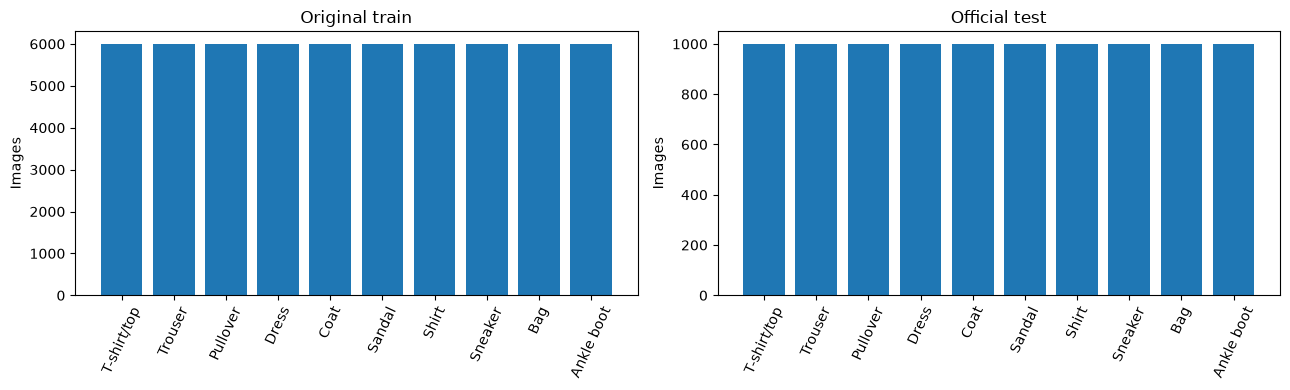

**Observation.** Original-train class counts range from 6,000 to 6,000; official-test counts range from 1,000 to 1,000.

In [4]:
original_counts = {'Original train':np.bincount(y,minlength=N_CLASSES),
                   'Official test':np.bincount(y_test,minlength=N_CLASSES)}
table(['Class','Original train','Train %','Official test','Test %'],
      [(name,int(original_counts['Original train'][k]),f"{100*original_counts['Original train'][k]/len(y):.1f}",
        int(original_counts['Official test'][k]),f"{100*original_counts['Official test'][k]/len(y_test):.1f}") for k,name in enumerate(NAMES)])
fig, axes = plt.subplots(1,2,figsize=(13,4))
for ax,(name,c) in zip(axes,original_counts.items()):
    ax.bar(NAMES,c)
    ax.set(title=name,ylabel='Images'); ax.tick_params(axis='x',rotation=65)
plt.tight_layout(); plt.show()
display(Markdown(f"**Observation.** Original-train class counts range from {original_counts['Original train'].min():,} to {original_counts['Original train'].max():,}; official-test counts range from {original_counts['Official test'].min():,} to {original_counts['Official test'].max():,}."))


## 4. Input Size and Pixel Range (Mandatory)

,Array,Shape,dtype,Min,Max
0,Original train,"(60000, 28, 28)",uint8,0,255
1,Official test,"(10000, 28, 28)",uint8,0,255


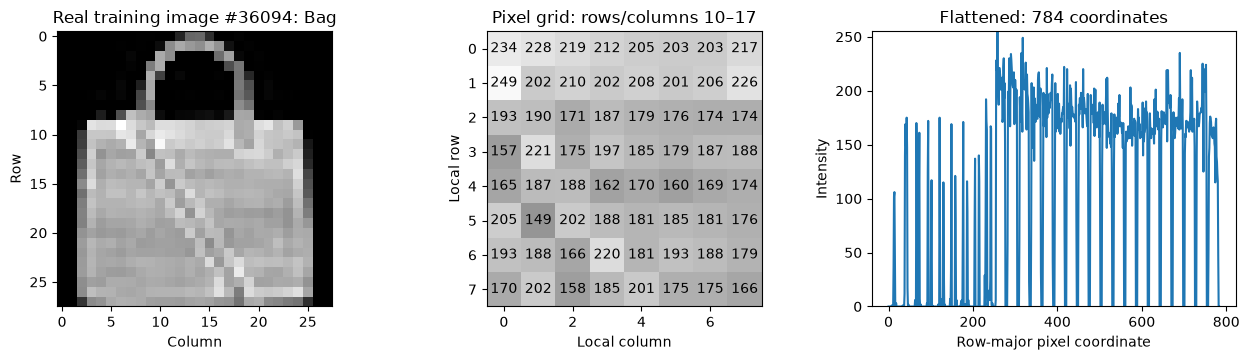

**Observation.** Every image is 28 × 28 with one grayscale channel. Flattening changes shape to 784 values. No resizing is needed.

In [5]:
example_index = int(train_idx[0])
example = X[example_index]
table(['Array','Shape','dtype','Min','Max'],
      [('Original train',X.shape,str(X.dtype),int(X.min()),int(X.max())),
       ('Official test',X_test.shape,str(X_test.dtype),int(X_test.min()),int(X_test.max()))])
fig, axes = plt.subplots(1,3,figsize=(13,3.7))
axes[0].imshow(example,cmap='gray',vmin=0,vmax=255)
axes[0].set(title=f'Real training image #{example_index}: {NAMES[y[example_index]]}',xlabel='Column',ylabel='Row')
patch = example[10:18,10:18]
axes[1].imshow(patch,cmap='gray',vmin=0,vmax=255)
for row in range(8):
    for col in range(8): axes[1].text(col,row,str(patch[row,col]),ha='center',va='center',
                                     color='black' if patch[row,col]>128 else 'white')
axes[1].set(title='Pixel grid: rows/columns 10–17',xlabel='Local column',ylabel='Local row')
axes[2].plot(example.reshape(-1))
axes[2].set(title=f'Flattened: {N_INPUTS} coordinates',xlabel='Row-major pixel coordinate',ylabel='Intensity',ylim=(0,255))
plt.tight_layout(); plt.show()
display(Markdown(f'**Observation.** Every image is {X.shape[1]} × {X.shape[2]} with one grayscale channel. Flattening changes shape to {N_INPUTS} values. No resizing is needed.'))


## 5. Imbalance Analysis from Original Data (Mandatory)

Compare the largest and smallest class counts.

In [6]:
imbalance = {name:float(c.max()/c.min()) for name,c in original_counts.items()}
table(['Set','Largest/smallest class'],[(name,f'{ratio:.3f}') for name,ratio in imbalance.items()])
display(Markdown('**Observation.** ' + '; '.join((f'{name}: {ratio:.3f}' for name, ratio in imbalance.items())) + '. Equal counts support unweighted cross-entropy as a baseline.'))


,Set,Largest/smallest class
0,Original train,1.000
1,Official test,1.000


**Observation.** Original train: 1.000; Official test: 1.000. Equal counts support unweighted cross-entropy as a baseline.

## 6. Representative Samples (Mandatory)

Four seeded training images per class.

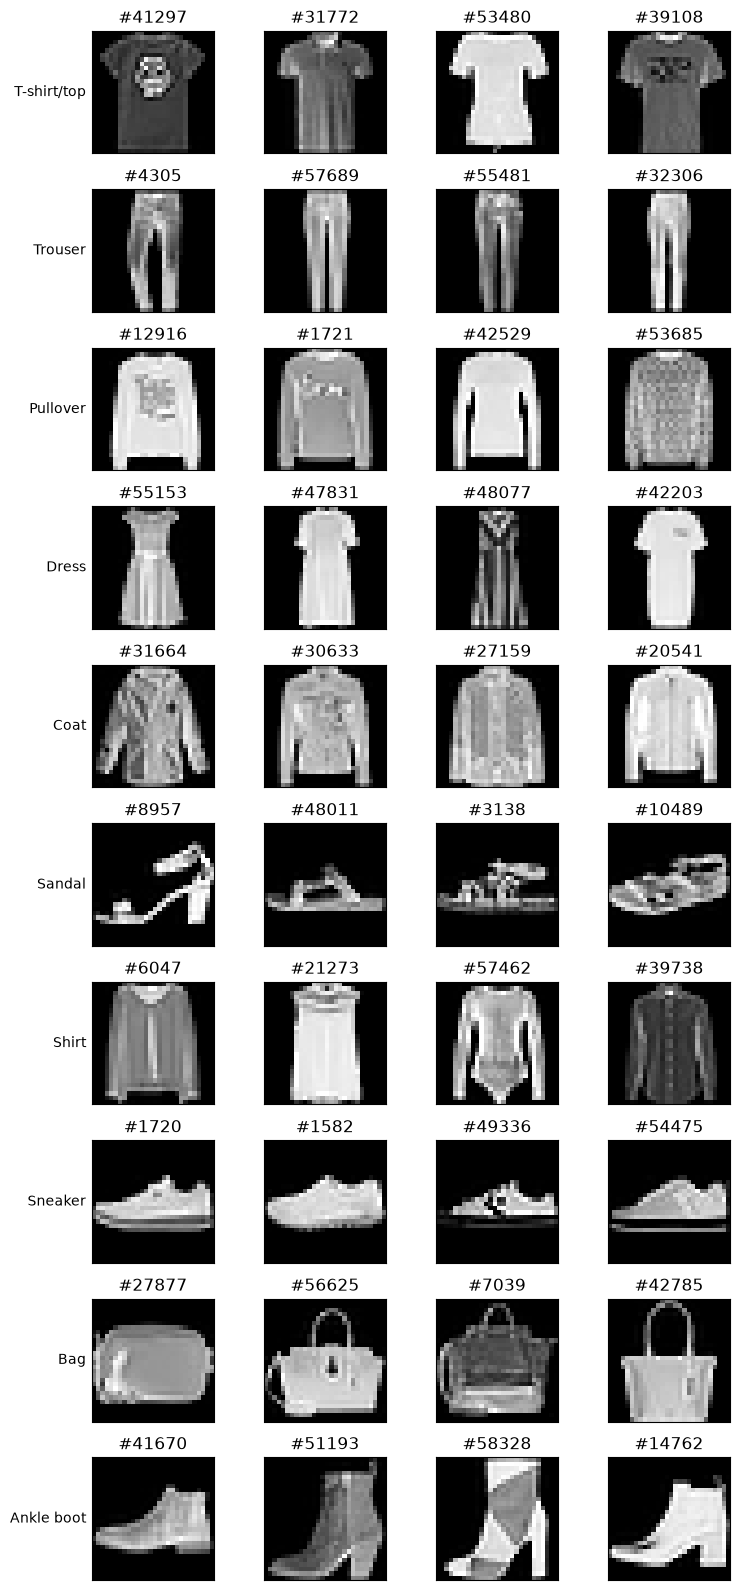

**Observation.** The gallery contains 40 seeded training examples with their original indices.

In [7]:
gallery_rng = np.random.default_rng(SPLIT_SEED)
gallery_indices = np.stack([gallery_rng.choice(train_idx[y[train_idx]==k],4,replace=False) for k in range(N_CLASSES)])
np.save(RUN_DIR/'gallery_indices.npy',gallery_indices)
def class_gallery(class_id=None):
    selected = list(range(N_CLASSES)) if class_id is None else [class_id]
    fig, axes = plt.subplots(len(selected),4,figsize=(8,1.6*len(selected)),squeeze=False)
    for row,k in enumerate(selected):
        for ax,index in zip(axes[row],gallery_indices[k]):
            ax.imshow(X[index],cmap='gray',vmin=0,vmax=255)
            ax.set_title(f'#{index}'); ax.set_xticks([]); ax.set_yticks([])
        axes[row,0].set_ylabel(NAMES[k],rotation=0,ha='right',va='center')
    plt.tight_layout(); plt.show()
class_gallery()
# Optional live selector; the full gallery above is the saved static report.
try:
    import ipywidgets as widgets
    gallery_choice = widgets.Dropdown(options=[(name,k) for k,name in enumerate(NAMES)],description='Class:')
    gallery_output = widgets.Output()
    def update_gallery(change):
        with gallery_output:
            gallery_output.clear_output(wait=True)
            class_gallery(gallery_choice.value)
    gallery_choice.observe(update_gallery,names='value')
    display(widgets.VBox([gallery_choice,gallery_output]))
except ImportError:
    display(Markdown('Optional class selector is unavailable; the full static gallery is above.'))
display(Markdown(f'**Observation.** The gallery contains {gallery_indices.size} seeded training examples with their original indices.'))


## 7. Data Splitting — Train / Validation / Test (Handbook 3.1)

- Stratified image split: 54,000 train / 6,000 validation; seed 42.
- Share saved indices across models and training seeds.
- Keep 10,000 official test images for descriptive checks only; all model scores use validation.

In [8]:
counts = {name:np.bincount(labels,minlength=N_CLASSES) for name,labels in
          [('Train',y[train_idx]),('Validation',y[val_idx]),('Test',y_test)]}
coverage = np.r_[train_idx,val_idx]
table(['Set','Images','Share of original training set'],
      [('Train',len(train_idx),f'{len(train_idx)/len(y):.1%}'),
       ('Validation',len(val_idx),f'{len(val_idx)/len(y):.1%}'),('Official test',len(y_test),'separate')])
assert len(np.unique(coverage)) == len(y)
assert np.array_equal(np.sort(coverage),np.arange(len(y)))
assert np.intersect1d(train_idx,val_idx).size == 0
display(pd.Series({'Train/validation shared indices':np.intersect1d(train_idx,val_idx).size,
       'Original training indices covered':len(np.unique(coverage))}, name="Value").to_frame())
display(Markdown('**Observation.** The two subsets are disjoint and cover the original training set exactly once.'))


,Set,Images,Share of original training set
0,Train,54000,90.0%
1,Validation,6000,10.0%
2,Official test,10000,separate


,Value
Train/validation shared indices,0
Original training indices covered,60000


**Observation.** The two subsets are disjoint and cover the original training set exactly once.

## 8. Label Distribution by Set and Post-split Balance Check

Check that each class retains 10% of each split.

,Class,Train,Validation,Test,Train %,Validation %,Test %
0,T-shirt/top,5400,600,1000,10.0,10.0,10.0
1,Trouser,5400,600,1000,10.0,10.0,10.0
2,Pullover,5400,600,1000,10.0,10.0,10.0
3,Dress,5400,600,1000,10.0,10.0,10.0
4,Coat,5400,600,1000,10.0,10.0,10.0
5,Sandal,5400,600,1000,10.0,10.0,10.0
6,Shirt,5400,600,1000,10.0,10.0,10.0
7,Sneaker,5400,600,1000,10.0,10.0,10.0
8,Bag,5400,600,1000,10.0,10.0,10.0
9,Ankle boot,5400,600,1000,10.0,10.0,10.0


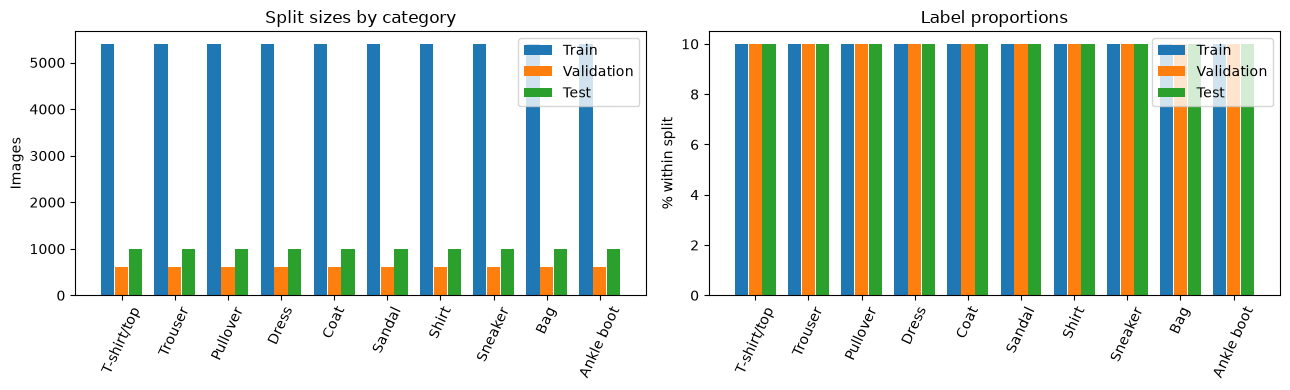

**Observation.** The largest train/validation class-proportion difference is 0.0000 percentage points.

In [9]:
table(['Class','Train','Validation','Test','Train %','Validation %','Test %'],
      [(name,*[int(c[k]) for c in counts.values()],*[f'{100*c[k]/c.sum():.1f}' for c in counts.values()])
       for k,name in enumerate(NAMES)])
fig,axes=plt.subplots(1,2,figsize=(13,4))
x=np.arange(N_CLASSES)
for j,(name,c) in enumerate(counts.items()):
    for ax,values in zip(axes,[c,100*c/c.sum()]):
        ax.bar(x+(j-1)*.26,values,width=.25,label=name)
for ax in axes:
    ax.set_xticks(x,NAMES,rotation=65); ax.legend()
axes[0].set(title='Split sizes by category',ylabel='Images')
axes[1].set(title='Label proportions',ylabel='% within split')
plt.tight_layout(); plt.show()
max_proportion_gap=float(np.max(np.abs(counts['Train']/len(train_idx)-counts['Validation']/len(val_idx))))
display(Markdown(f'**Observation.** The largest train/validation class-proportion difference is {100 * max_proportion_gap:.4f} percentage points.'))


## 9. Preprocessing (Handbook 3.1)

Scale by 255, then apply `z = (pixel/255 − mean)/std`. Fit mean/std on training pixels only; reuse for validation. No augmentation.

Image batch: (128, 1, 28, 28) torch.float32 | labels: (128,) torch.int64
Train batches: 422 | validation batches: 47
Batch min/max/mean: -0.8104236721992493 2.021156072616577 -0.008760523051023483


,Representation,Population mean,Population std,Min,Max
0,Raw bytes,72.983297,90.055735,0,255
1,Scaled,0.286209,0.353160,0.0000,1.0000
2,Standardized,0.000000,1.000000,-0.8104,2.0212


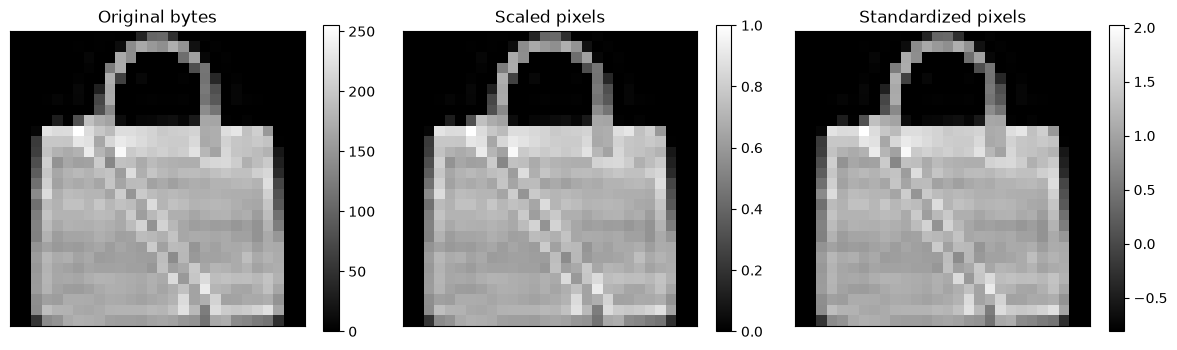

,Loader,Batches,Last batch size,drop_last
0,Train,422,112,False
1,Validation,47,112,False


**Observation.** Training-fitted mean/std are 0.286209/0.353160. All 54,000 training samples are retained, including the final 112-image batch. Only training is shuffled.

In [10]:
pixels = X[train_idx]
hist = np.bincount(pixels.reshape(-1),minlength=256)
levels = np.arange(256,dtype=np.float64)/255
probability = hist/hist.sum()
mean = float(probability @ levels)
std = float(np.sqrt(probability @ ((levels-mean)**2)))
assert std > 0
(RUN_DIR/'normalization.json').write_text(json.dumps({'mean':mean,'std':std,'fit_indices_sha256':hashlib.sha256(train_idx.tobytes()).hexdigest()},indent=2))
table(['Representation','Population mean','Population std','Min','Max'],
      [('Raw bytes',f'{mean*255:.6f}',f'{std*255:.6f}',int(pixels.min()),int(pixels.max())),
       ('Scaled',f'{mean:.6f}',f'{std:.6f}',f'{pixels.min()/255:.4f}',f'{pixels.max()/255:.4f}'),
       ('Standardized',f'{probability@((levels-mean)/std):.6f}',f'{np.sqrt(probability@(((levels-mean)/std)**2)):.6f}',f'{(pixels.min()/255-mean)/std:.4f}',f'{(pixels.max()/255-mean)/std:.4f}')])
fig,axes=plt.subplots(1,3,figsize=(12,3.5))
for ax,values,title,lo,hi in zip(axes,[example,example/255,(example/255-mean)/std],
        ['Original bytes','Scaled pixels','Standardized pixels'],[0,0,-mean/std],[255,1,(1-mean)/std]):
    im=ax.imshow(values,cmap='gray',vmin=lo,vmax=hi)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([]); fig.colorbar(im,ax=ax)
plt.tight_layout(); plt.show()
class FashionImages(Dataset):
    def __init__(self, images, labels, mean, std):
        normalized = (images.astype(np.float32) / np.float32(255) - np.float32(mean)) / np.float32(std)
        self.images = torch.from_numpy(normalized).unsqueeze(1)
        self.labels = torch.from_numpy(labels.astype(np.int64))

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return self.images[index], self.labels[index]

base = FashionImages(X, y, mean, std)
train_data, val_data = Subset(base, train_idx.tolist()), Subset(base, val_idx.tolist())

def make_loaders(batch_size, seed):
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True,
                              generator=torch.Generator().manual_seed(seed), num_workers=0)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=0)
    return train_loader, val_loader

train_loader, val_loader = make_loaders(batch_size=128, seed=SPLIT_SEED)
xb, yb = next(iter(train_loader))
assert xb.shape == (len(yb), 1, *X.shape[1:])
assert xb.dtype == torch.float32 and yb.dtype == torch.int64
assert torch.isfinite(xb).all()
seen = np.concatenate(list(train_loader.batch_sampler))
assert np.array_equal(np.sort(seen), np.arange(len(train_idx)))
print('Image batch:', tuple(xb.shape), xb.dtype, '| labels:', tuple(yb.shape), yb.dtype)
print('Train batches:', len(train_loader), '| validation batches:', len(val_loader))
print('Batch min/max/mean:', xb.min().item(), xb.max().item(), xb.mean().item())
last_train_size = len(train_idx) % 128 or 128
last_val_size = len(val_idx) % 128 or 128
assert sum(len(batch) for batch in train_loader.batch_sampler) == len(train_idx)
assert sum(len(batch) for batch in val_loader.batch_sampler) == len(val_idx)
table(['Loader','Batches','Last batch size','drop_last'],
      [('Train',len(train_loader),last_train_size,train_loader.drop_last),
       ('Validation',len(val_loader),last_val_size,val_loader.drop_last)])
display(Markdown(f'**Observation.** Training-fitted mean/std are {mean:.6f}/{std:.6f}. All {len(train_idx):,} training samples are retained, including the final {last_train_size}-image batch. Only training is shuffled.'))
del pixels

## 10. Additional Analysis (Optional)

Use training images for fitted analyses and sampled galleries. Keep all images and pixels in the baseline.

In [11]:
assert np.intersect1d(gallery_indices.ravel(), val_idx).size == 0
print('Additional analysis uses the saved training subset:', len(train_idx), 'images')

Additional analysis uses the saved training subset: 54000 images


### 10.1 Pixel structure

Plot pixel means, population variances and intensity counts on the [0,1] scale.

,Value
Zero-valued pixels,50.2%
Zero-variance locations,0
Variance below threshold,11


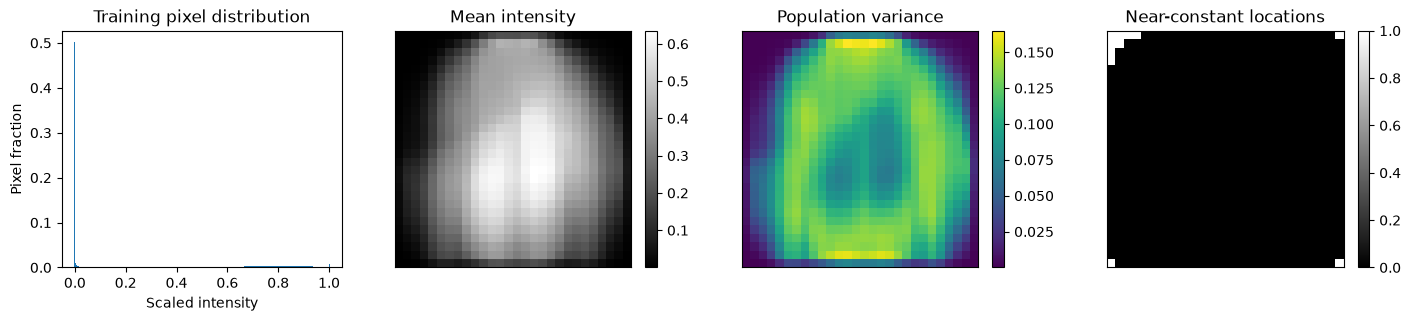

**Observed:** 50.2% of training pixels are exactly zero; 11/784 locations have variance below 0.0001. All coordinates are retained.

In [12]:
EDA_SEED = 42
FOREGROUND_THRESHOLD = 26                 # uint8 intensity; foreground means pixel > threshold
NEAR_CONSTANT_VARIANCE = 1e-4             # variance in [0,1] intensity units
PCA_PER_CLASS, VIEW_PER_CLASS = 600, 200
PCA_COMPONENTS = 128
TSNE_PERPLEXITY, TSNE_ITERATIONS = 30, 750
EDA_DIR = RUN_DIR / "eda"
EDA_DIR.mkdir(exist_ok=True)

# Keep the full pixel summaries readable; pairwise searches below use a bounded sample.
eda_pixels = X[train_idx].astype(np.float32) / 255.0
eda_labels = y[train_idx]
pixel_mean = eda_pixels.mean(axis=0, dtype=np.float64)
pixel_variance = eda_pixels.var(axis=0, dtype=np.float64)
pixel_counts = np.bincount(X[train_idx].reshape(-1), minlength=256)
zero_fraction = float(pixel_counts[0] / pixel_counts.sum())
zero_variance_pixels = int(np.sum(pixel_variance == 0))
near_constant_pixels = int(np.sum(pixel_variance < NEAR_CONSTANT_VARIANCE))
display(pd.Series({"Zero-valued pixels": f"{zero_fraction:.1%}",
       "Zero-variance locations": zero_variance_pixels,
       "Variance below threshold": near_constant_pixels}, name="Value").to_frame())

fig, axes = plt.subplots(1, 4, figsize=(14, 3.1), layout="constrained")
axes[0].bar(np.arange(256) / 255, pixel_counts / pixel_counts.sum(), width=1/255)
axes[0].set(title="Training pixel distribution", xlabel="Scaled intensity", ylabel="Pixel fraction")
for ax, values, title, cmap in zip(axes[1:],
        [pixel_mean, pixel_variance, pixel_variance < NEAR_CONSTANT_VARIANCE],
        ["Mean intensity", "Population variance", "Near-constant locations"],
        ["gray", None, "gray"]):
    im = ax.imshow(values, cmap=cmap)
    ax.set(title=title, xticks=[], yticks=[])
    fig.colorbar(im, ax=ax)
plt.show()
display(Markdown(f'**Observed:** {zero_fraction:.1%} of training pixels are exactly zero; {near_constant_pixels}/{N_INPUTS} locations have variance below {NEAR_CONSTANT_VARIANCE:g}. All coordinates are retained.'))


### 10.2 Brightness, contrast and foreground shape

Brightness = mean intensity; contrast = standard deviation. Foreground = pixels above the threshold. Boxes and coverage describe this mask; these are not defect scores.

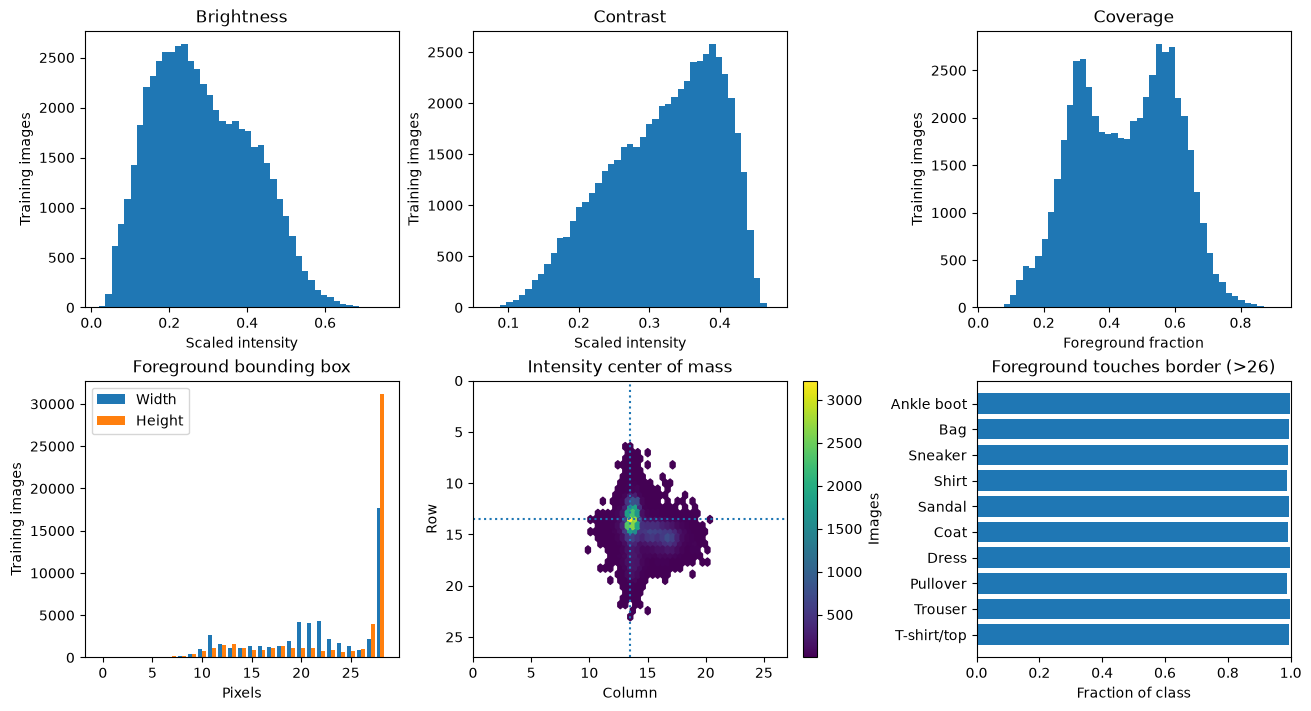

,Feature,5th percentile,Median,95th percentile
0,brightness,0.101,0.272,0.503
1,contrast,0.178,0.332,0.428
2,coverage,0.214,0.458,0.673
3,width,11.000,22.000,28.000
4,height,11.000,28.000,28.000
5,center_x,13.160,13.943,17.145
6,center_y,11.989,14.157,16.860


**Observed:** 99.4% touch a border at this threshold; 0 masks are empty. Median foreground size is 22 × 28 pixels.

In [13]:
def foreground_features(images, threshold):
    mask = images > threshold
    occupied_rows, occupied_cols = mask.any(axis=2), mask.any(axis=1)
    present = mask.any(axis=(1, 2))
    height = np.where(present, images.shape[1] - occupied_rows[:, ::-1].argmax(axis=1)
                      - occupied_rows.argmax(axis=1), 0)
    width = np.where(present, images.shape[2] - occupied_cols[:, ::-1].argmax(axis=1)
                     - occupied_cols.argmax(axis=1), 0)
    touches = (mask[:, 0, :].any(axis=1) | mask[:, -1, :].any(axis=1)
               | mask[:, :, 0].any(axis=1) | mask[:, :, -1].any(axis=1))
    return {"coverage": mask.mean(axis=(1, 2)), "width": width, "height": height,
            "border_touch": touches, "empty_mask": ~present}

quality = foreground_features(X[train_idx], FOREGROUND_THRESHOLD)
quality["brightness"] = eda_pixels.mean(axis=(1, 2))
quality["contrast"] = eda_pixels.std(axis=(1, 2))
intensity_mass = eda_pixels.sum(axis=(1, 2), dtype=np.float64)
row_mass = eda_pixels.sum(axis=2, dtype=np.float64)
col_mass = eda_pixels.sum(axis=1, dtype=np.float64)
quality["center_y"] = np.divide(row_mass @ np.arange(28), intensity_mass,
                               out=np.full(len(train_idx), np.nan), where=intensity_mass > 0)
quality["center_x"] = np.divide(col_mass @ np.arange(28), intensity_mass,
                               out=np.full(len(train_idx), np.nan), where=intensity_mass > 0)
np.savez_compressed(EDA_DIR / "image_features.npz", indices=train_idx, **quality)

fig, axes = plt.subplots(2, 3, figsize=(13, 7), layout="constrained")
for ax, key in zip(axes[0], ["brightness", "contrast", "coverage"]):
    ax.hist(quality[key], bins=45)
    ax.set(title=key.capitalize(), xlabel="Scaled intensity" if key != "coverage" else "Foreground fraction",
           ylabel="Training images")
axes[1, 0].hist([quality["width"], quality["height"]], bins=np.arange(30)-.5,
                label=["Width", "Height"])
axes[1, 0].set(title="Foreground bounding box", xlabel="Pixels", ylabel="Training images")
axes[1, 0].legend()
position = axes[1, 1].hexbin(quality["center_x"], quality["center_y"], gridsize=25, mincnt=1)
axes[1, 1].set(title="Intensity center of mass", xlabel="Column", ylabel="Row", xlim=(0,27), ylim=(27,0))
axes[1, 1].axvline(13.5, linestyle=":")
axes[1, 1].axhline(13.5, linestyle=":")
fig.colorbar(position, ax=axes[1, 1], label="Images")
border_rates = [quality["border_touch"][eda_labels == c].mean() for c in range(N_CLASSES)]
axes[1, 2].barh(NAMES, border_rates)
axes[1, 2].set(title=f"Foreground touches border (>{FOREGROUND_THRESHOLD})", xlabel="Fraction of class", xlim=(0,1))
plt.show()
table(["Feature", "5th percentile", "Median", "95th percentile"],
      [[key, *[f"{v:.3f}" for v in np.nanpercentile(quality[key], [5, 50, 95])]]
       for key in ["brightness", "contrast", "coverage", "width", "height", "center_x", "center_y"]])
display(Markdown(f"**Observed:** {quality['border_touch'].mean():.1%} touch a border at this threshold; {quality['empty_mask'].sum():,} masks are empty. Median foreground size is {np.median(quality['width']):.0f} × {np.median(quality['height']):.0f} pixels."))


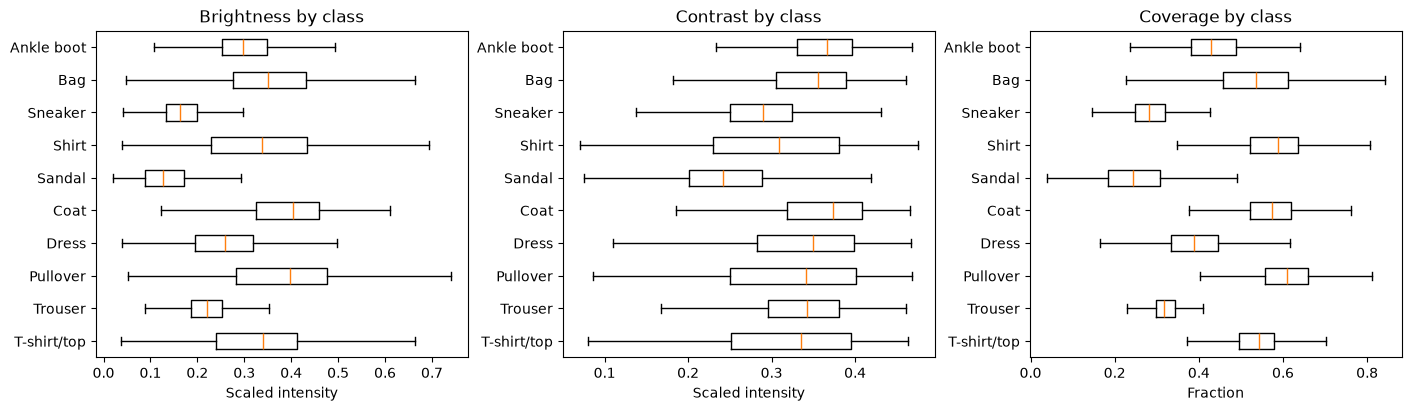

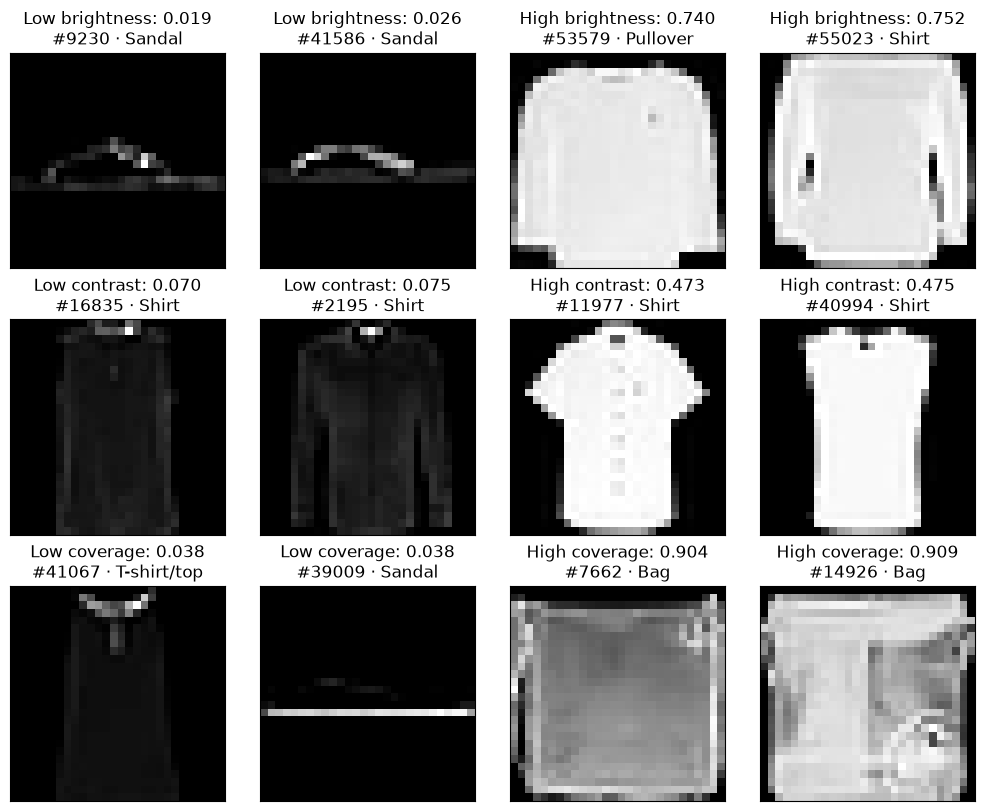

**Observed:** median brightness ranges from 0.127 (Sandal) to 0.404 (Coat). The gallery shows the two lowest and two highest values for each proxy.

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), layout="constrained")
for ax, key in zip(axes, ["brightness", "contrast", "coverage"]):
    boxes = ax.boxplot([quality[key][eda_labels == c] for c in range(N_CLASSES)],
                       orientation="horizontal", showfliers=False,
                       tick_labels=NAMES)
    ax.set(title=f"{key.capitalize()} by class", xlabel="Scaled intensity" if key != "coverage" else "Fraction")
plt.show()

# Stable sort makes the inspection rule explicit even when values tie.
tail_indices = {}
fig, axes = plt.subplots(3, 4, figsize=(10, 8), layout="constrained")
for row, key in enumerate(["brightness", "contrast", "coverage"]):
    order = np.argsort(quality[key], kind="stable")
    chosen = np.r_[order[:2], order[-2:]]
    tail_indices[key] = train_idx[chosen].tolist()
    for col, local_index in enumerate(chosen):
        original_index = int(train_idx[local_index])
        axes[row, col].imshow(X[original_index], cmap="gray", vmin=0, vmax=255)
        axes[row, col].set(title=f"{'Low' if col < 2 else 'High'} {key}: {quality[key][local_index]:.3f}\n"
                                 f"#{original_index} · {NAMES[y[original_index]]}", xticks=[], yticks=[])
plt.show()
class_brightness = np.array([np.median(quality["brightness"][eda_labels == c]) for c in range(N_CLASSES)])
display(Markdown(f'**Observed:** median brightness ranges from {class_brightness.min():.3f} ({NAMES[class_brightness.argmin()]}) to {class_brightness.max():.3f} ({NAMES[class_brightness.argmax()]}). The gallery shows the two lowest and two highest values for each proxy.'))


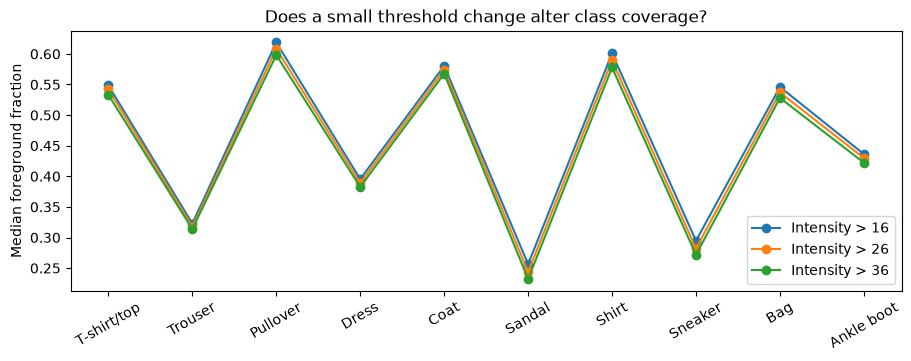

,Threshold,Median coverage,Border touch,Median box (w × h)
0,16,47.1%,99.6%,22 × 28
1,26,45.8%,99.4%,22 × 28
2,36,44.5%,98.9%,22 × 28


**Observed:** the largest class-median shift is 1.3% of image area. The lowest- and highest-coverage classes stay the same.

In [15]:
# Sensitivity: ten gray levels either side of the baseline foreground threshold.
thresholds = [FOREGROUND_THRESHOLD - 10, FOREGROUND_THRESHOLD, FOREGROUND_THRESHOLD + 10]
assert all(0 <= threshold < 255 for threshold in thresholds)
sensitivity = []
for threshold in thresholds:
    features = foreground_features(X[train_idx], threshold)
    medians = np.array([np.median(features["coverage"][eda_labels == c]) for c in range(N_CLASSES)])
    sensitivity.append({"threshold": threshold, "coverage_by_class": medians.tolist(),
                        "median_coverage": float(np.median(features["coverage"])),
                        "border_fraction": float(features["border_touch"].mean()),
                        "median_width": float(np.median(features["width"])),
                        "median_height": float(np.median(features["height"]))})
fig, ax = plt.subplots(figsize=(9, 3.5), layout="constrained")
for row in sensitivity:
    ax.plot(np.arange(N_CLASSES), row["coverage_by_class"], marker="o", label=f"Intensity > {row['threshold']}")
ax.set(xticks=np.arange(N_CLASSES), xticklabels=NAMES, ylabel="Median foreground fraction",
       title="Does a small threshold change alter class coverage?")
ax.tick_params(axis="x", rotation=30)
ax.legend()
plt.show()
table(["Threshold", "Median coverage", "Border touch", "Median box (w × h)"],
      [[r["threshold"], f"{r['median_coverage']:.1%}", f"{r['border_fraction']:.1%}",
        f"{r['median_width']:.0f} × {r['median_height']:.0f}"] for r in sensitivity])
coverage_matrix = np.array([r["coverage_by_class"] for r in sensitivity])
coverage_shift = float(np.max(np.abs(coverage_matrix - coverage_matrix[1])))
stable_extremes = (len(set(coverage_matrix.argmin(axis=1))) == 1
                   and len(set(coverage_matrix.argmax(axis=1))) == 1)
sensitivity_conclusion = ("The lowest- and highest-coverage classes stay the same."
                         if stable_extremes else "The extreme class ranking changes with the threshold.")
display(Markdown(f'**Observed:** the largest class-median shift is {coverage_shift:.1%} of image area. {sensitivity_conclusion}'))


### 10.3 Class structure and real exemplars

Show class means, variances, and nearest/farthest real images by RMS distance on scaled pixels.

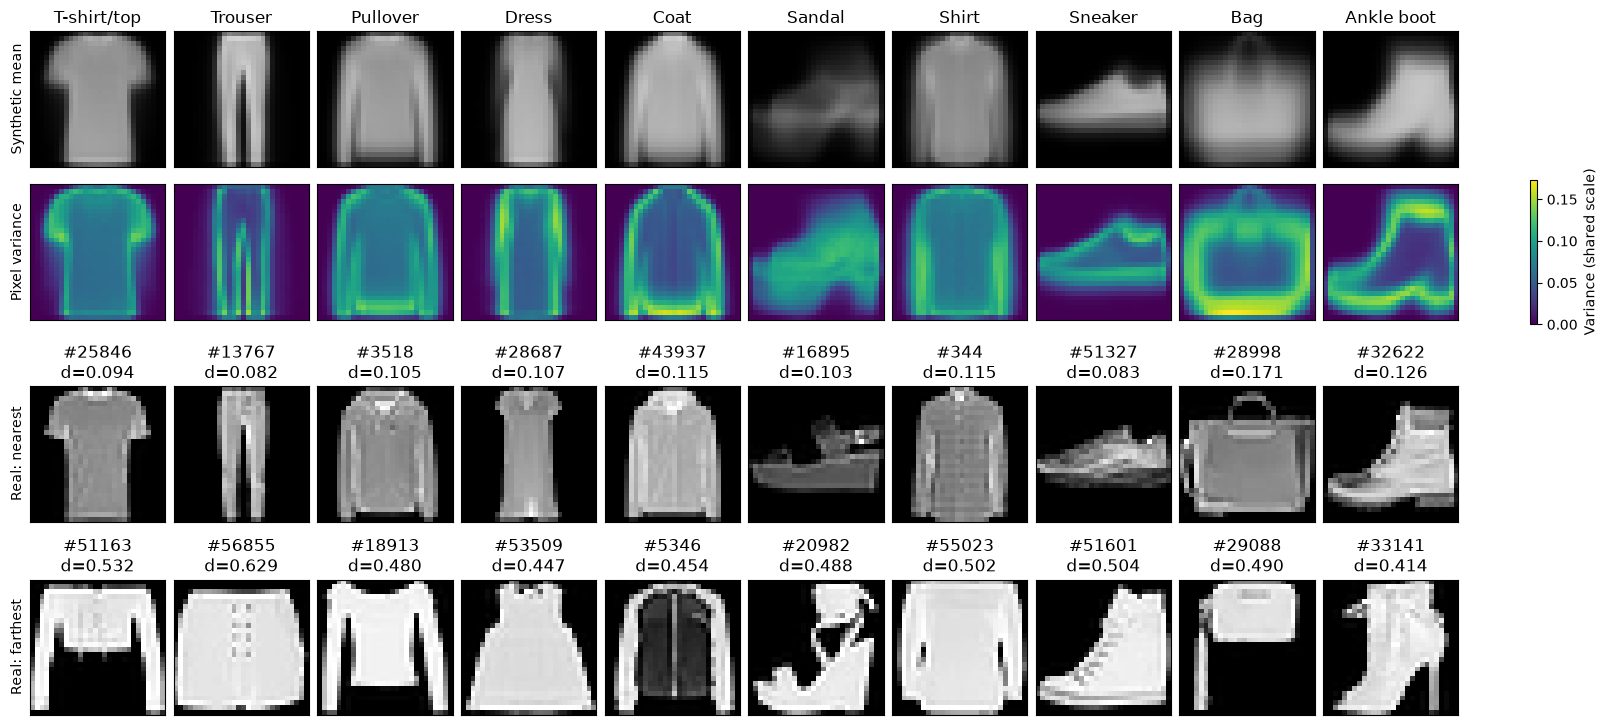

,Class,Median RMS distance to its mean
0,T-shirt/top,0.219
1,Trouser,0.162
2,Pullover,0.239
3,Dress,0.204
4,Coat,0.222
5,Sandal,0.203
6,Shirt,0.239
7,Sneaker,0.167
8,Bag,0.276
9,Ankle boot,0.215


**Observed:** Bag has the greatest median distance to its centroid (0.276); Trouser has the smallest (0.162).

In [16]:
class_means, class_variances, centroid_exemplars = [], [], []
class_spread = []
for c in range(N_CLASSES):
    positions = np.flatnonzero(eda_labels == c)
    class_pixels = eda_pixels[positions]
    centroid = class_pixels.mean(axis=0, dtype=np.float64)
    class_means.append(centroid)
    class_variances.append(class_pixels.var(axis=0, dtype=np.float64))
    distances = np.sqrt(np.mean((class_pixels - centroid) ** 2, axis=(1, 2)))
    near, far = int(np.argmin(distances)), int(np.argmax(distances))
    centroid_exemplars.append({"class": c, "near": int(train_idx[positions[near]]),
                              "far": int(train_idx[positions[far]]),
                              "near_distance": float(distances[near]), "far_distance": float(distances[far])})
    class_spread.append(float(np.median(distances)))
class_means, class_variances = np.array(class_means), np.array(class_variances)
fig, axes = plt.subplots(4, N_CLASSES, figsize=(16, 7.2), layout="constrained")
for c, examples in enumerate(centroid_exemplars):
    axes[0, c].imshow(class_means[c], cmap="gray", vmin=0, vmax=1)
    axes[0, c].set_title(NAMES[c])
    variance_im = axes[1, c].imshow(class_variances[c], vmin=0, vmax=class_variances.max())
    for row, key in [(2, "near"), (3, "far")]:
        index = examples[key]
        axes[row, c].imshow(X[index], cmap="gray", vmin=0, vmax=255)
        axes[row, c].set_title(f"#{index}\nd={examples[key + '_distance']:.3f}")
    for row in range(4):
        axes[row, c].set(xticks=[], yticks=[])
for row, label in enumerate(["Synthetic mean", "Pixel variance", "Real: nearest", "Real: farthest"]):
    axes[row, 0].set_ylabel(label)
fig.colorbar(variance_im, ax=axes[1, :], label="Variance (shared scale)")
plt.show()
table(["Class", "Median RMS distance to its mean"],
      [[NAMES[c], f"{class_spread[c]:.3f}"] for c in range(N_CLASSES)])
display(Markdown(f'**Observed:** {NAMES[int(np.argmax(class_spread))]} has the greatest median distance to its centroid ({max(class_spread):.3f}); {NAMES[int(np.argmin(class_spread))]} has the smallest ({min(class_spread):.3f}).'))


### 10.4 Between-class similarity and bounded neighbor search

Compare RMS pixel distances on a balanced sample. Draw within/between-class pairs with replacement; distances describe appearance, not classifier errors.

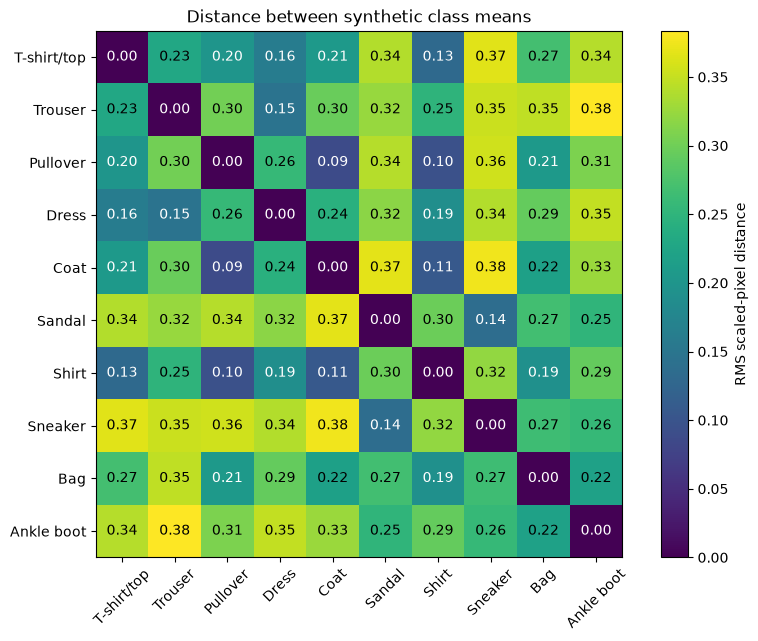

,Class A,Class B,Centroid RMS distance
0,Pullover,Coat,0.088
1,Pullover,Shirt,0.096
2,Coat,Shirt,0.107
3,T-shirt/top,Shirt,0.132
4,Sandal,Sneaker,0.137


In [17]:
from sklearn.neighbors import NearestNeighbors

def balanced_training_sample(per_class, seed):
    rng = np.random.default_rng(seed)
    return np.concatenate([rng.choice(train_idx[y[train_idx] == c], size=per_class, replace=False)
                           for c in range(N_CLASSES)])

eda_sample_idx = balanced_training_sample(VIEW_PER_CLASS, EDA_SEED)
eda_sample_flat = X[eda_sample_idx].reshape(len(eda_sample_idx), -1).astype(np.float32) / 255
eda_sample_y = y[eda_sample_idx]
np.save(EDA_DIR / "neighbor_projection_indices.npy", eda_sample_idx)
centroid_distance = np.sqrt(((class_means[:, None] - class_means[None, :]) ** 2).mean(axis=(2, 3)))
fig, ax = plt.subplots(figsize=(8, 6.3), layout="constrained")
im = ax.imshow(centroid_distance)
ax.set(xticks=range(N_CLASSES), yticks=range(N_CLASSES), xticklabels=NAMES, yticklabels=NAMES,
       title="Distance between synthetic class means")
ax.tick_params(axis="x", rotation=45)
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax.text(j, i, f"{centroid_distance[i,j]:.2f}", ha="center", va="center",
                color="white" if centroid_distance[i,j] < centroid_distance.max() * .55 else "black")
fig.colorbar(im, ax=ax, label="RMS scaled-pixel distance")
plt.show()
upper = np.triu_indices(N_CLASSES, 1)
closest_order = np.argsort(centroid_distance[upper], kind="stable")[:5]
closest_centroid_pairs = [(int(upper[0][i]), int(upper[1][i])) for i in closest_order]
table(["Class A", "Class B", "Centroid RMS distance"],
      [[NAMES[a], NAMES[b], f"{centroid_distance[a,b]:.3f}"] for a,b in closest_centroid_pairs])

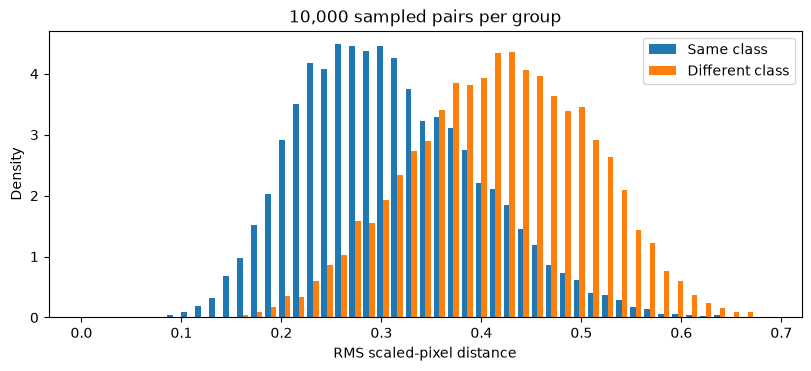

,Pair type,5th percentile,Median,95th percentile
0,Same class,0.181,0.301,0.466
1,Different class,0.268,0.420,0.561


**Observed:** the median distances are 0.301 within class and 0.420 between classes. 10.5% of sampled different-class pairs lie below the same-class median.

In [18]:
rng_pairs = np.random.default_rng(EDA_SEED + 1)
within_pairs, between_pairs = [], []
for c in range(N_CLASSES):
    positions = np.flatnonzero(eda_sample_y == c)
    anchors = rng_pairs.choice(positions, size=1000, replace=True)
    # Nonzero cyclic offsets prevent pairing an image with itself.
    partners = positions[(np.searchsorted(positions, anchors)
                          + rng_pairs.integers(1, len(positions), size=len(anchors))) % len(positions)]
    within_pairs.extend(zip(anchors, partners))
    other_positions = np.flatnonzero(eda_sample_y != c)
    between_pairs.extend(zip(anchors, rng_pairs.choice(other_positions, len(anchors), replace=True)))
within_pairs, between_pairs = np.array(within_pairs), np.array(between_pairs)
within_dist = np.sqrt(np.mean((eda_sample_flat[within_pairs[:,0]] - eda_sample_flat[within_pairs[:,1]]) ** 2, axis=1))
between_dist = np.sqrt(np.mean((eda_sample_flat[between_pairs[:,0]] - eda_sample_flat[between_pairs[:,1]]) ** 2, axis=1))
np.savez_compressed(EDA_DIR / "distance_pairs.npz", within_indices=eda_sample_idx[within_pairs],
                    between_indices=eda_sample_idx[between_pairs], within_distance=within_dist, between_distance=between_dist)
fig, ax = plt.subplots(figsize=(8, 3.6), layout="constrained")
bins = np.linspace(0, max(within_dist.max(), between_dist.max()), 50)
ax.hist([within_dist, between_dist], bins=bins, density=True,
        label=["Same class", "Different class"])
ax.set(xlabel="RMS scaled-pixel distance", ylabel="Density", title="10,000 sampled pairs per group")
ax.legend()
plt.show()
table(["Pair type", "5th percentile", "Median", "95th percentile"],
      [[name, *[f"{v:.3f}" for v in np.percentile(values, [5,50,95])]]
       for name, values in [("Same class", within_dist), ("Different class", between_dist)]])
different_below_within_median = float(np.mean(between_dist < np.median(within_dist)))
display(Markdown(f'**Observed:** the median distances are {np.median(within_dist):.3f} within class and {np.median(between_dist):.3f} between classes. {different_below_within_median:.1%} of sampled different-class pairs lie below the same-class median.'))


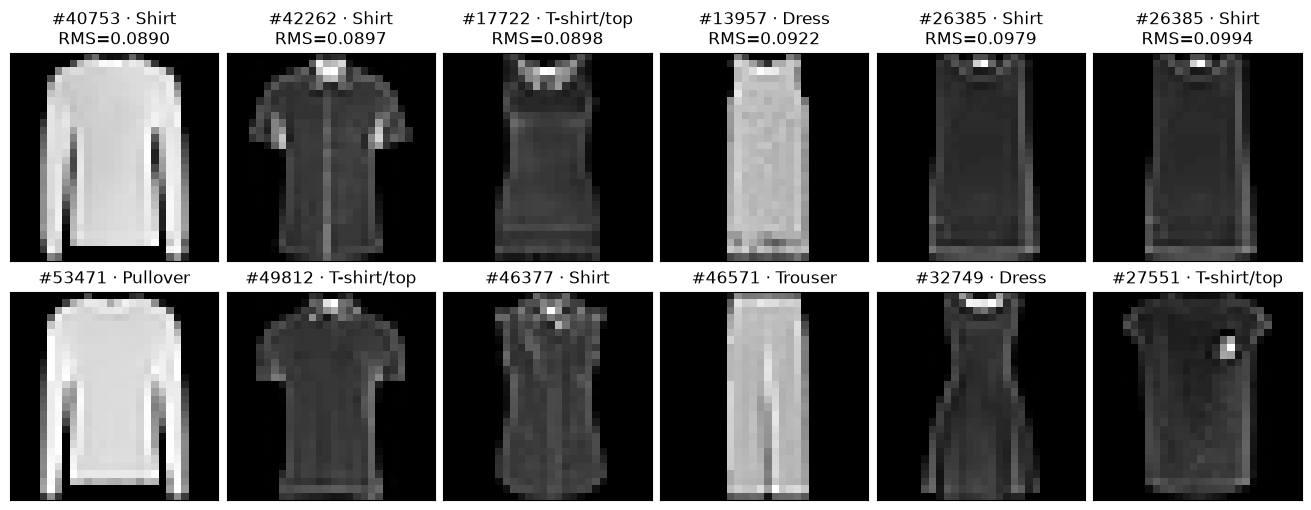

**Observed:** the closest class means are Pullover and Coat (RMS=0.088). Above are the six closest unique cross-class pairs found among 2,000 balanced training images.

In [19]:
# For each anchor, search only differently labeled candidates in the bounded sample.
cross_neighbors = {}
for c in range(N_CLASSES):
    anchors = np.flatnonzero(eda_sample_y == c)
    candidates = np.flatnonzero(eda_sample_y != c)
    search = NearestNeighbors(n_neighbors=1, algorithm="brute", metric="euclidean", n_jobs=1)
    search.fit(eda_sample_flat[candidates])
    distances, neighbors = search.kneighbors(eda_sample_flat[anchors])
    for a, distance, neighbor in zip(anchors, distances[:,0], neighbors[:,0]):
        b = candidates[neighbor]
        pair = tuple(sorted((int(eda_sample_idx[a]), int(eda_sample_idx[b]))))
        cross_neighbors[pair] = float(distance / np.sqrt(N_INPUTS))
cross_neighbor_pairs = sorted(cross_neighbors.items(), key=lambda item: (item[1], item[0]))[:6]
fig, axes = plt.subplots(2, 6, figsize=(13, 5), layout="constrained")
for col, ((a, b), distance) in enumerate(cross_neighbor_pairs):
    for row, index in enumerate((a,b)):
        axes[row,col].imshow(X[index], cmap="gray", vmin=0, vmax=255)
        axes[row,col].set(title=f"#{index} · {NAMES[y[index]]}" + (f"\nRMS={distance:.4f}" if row == 0 else ""),
                          xticks=[], yticks=[])
plt.show()
closest_a, closest_b = closest_centroid_pairs[0]
display(Markdown(f'**Observed:** the closest class means are {NAMES[closest_a]} and {NAMES[closest_b]} (RMS={centroid_distance[closest_a, closest_b]:.3f}). Above are the six closest unique cross-class pairs found among {len(eda_sample_idx):,} balanced training images.'))


### 10.5 Exact duplicates and near-duplicate candidates

Hash full images and confirm pixel equality, including test overlap. Count extra copies and label conflicts. Near-duplicate candidates use sampled pixel distances; the split stays fixed.

In [20]:
from collections import defaultdict

all_images = np.concatenate([X, X_test], axis=0)
all_labels = np.concatenate([y, y_test])
image_hashes = np.array([hashlib.sha256(image.tobytes()).hexdigest() for image in all_images])
hash_groups = defaultdict(list)
for index, digest in enumerate(image_hashes):
    hash_groups[str(digest)].append(index)
duplicate_groups = [indices for indices in hash_groups.values() if len(indices) > 1]
for indices in duplicate_groups:
    assert all(np.array_equal(all_images[indices[0]], all_images[i]) for i in indices[1:])
conflict_groups = [indices for indices in duplicate_groups if len(set(all_labels[indices].tolist())) > 1]
split_members = {"Training": train_idx, "Validation": val_idx,
                 "Official test": np.arange(len(X), len(all_images))}
split_hashes = {name: set(image_hashes[indices]) for name, indices in split_members.items()}
duplicate_rows = []
for name, indices in {**split_members, "Original train": np.arange(len(X)),
                       "All records": np.arange(len(all_images))}.items():
    hashes, counts = np.unique(image_hashes[indices], return_counts=True)
    repeated = hashes[counts > 1]
    conflicts = sum(len(set(all_labels[indices[image_hashes[indices] == h]].tolist())) > 1 for h in repeated)
    duplicate_rows.append([name, int(np.sum(counts > 1)), int(np.sum(counts[counts > 1] - 1)), conflicts])
table(["Scope", "Duplicate groups", "Extra records", "Conflicting groups"], duplicate_rows)
overlap_rows, exact_overlap = [], {}
for left, right in [("Training", "Validation"), ("Training", "Official test"), ("Validation", "Official test")]:
    shared = split_hashes[left] & split_hashes[right]
    left_count = int(np.isin(image_hashes[split_members[left]], list(shared)).sum())
    right_count = int(np.isin(image_hashes[split_members[right]], list(shared)).sum())
    conflicting_shared = sum(len(set(all_labels[hash_groups[h]].tolist())) > 1 for h in shared)
    overlap_rows.append([left + " ↔ " + right, len(shared), left_count, right_count, conflicting_shared])
    exact_overlap[left + " / " + right] = {"shared_hashes": len(shared),
                                            "left_records": left_count, "right_records": right_count}
table(["Splits", "Shared images", "Left records", "Right records", "Conflicting hashes*"], overlap_rows)
display(Markdown("*Conflicting hashes use labels across all occurrences of that hash. "
    "A shared image is one distinct pixel array, even if it occurs more than once in either split."))
duplicate_evidence = {"duplicate_groups": duplicate_groups, "conflict_groups": conflict_groups,
                      "overlap": exact_overlap, "test_index_offset": len(X)}
(EDA_DIR / "exact_duplicates.json").write_text(json.dumps(duplicate_evidence, indent=2))
display(Markdown(f"**Observed:** {len(duplicate_groups):,} exact duplicate groups exist across the "
    f"original train and test arrays, including {len(conflict_groups):,} label-conflict groups. "
    f"Training and validation share {exact_overlap['Training / Validation']['shared_hashes']:,} distinct "
    "images. " + ("This overlap limits evaluation independence. "
    if exact_overlap['Training / Validation']['shared_hashes'] else "No exact training/validation overlap was found. ") + ""
    ""))
del all_images

,Scope,Duplicate groups,Extra records,Conflicting groups
0,Training,0,0,0
1,Validation,0,0,0
2,Official test,0,0,0
3,Original train,0,0,0
4,All records,0,0,0


,Splits,Shared images,Left records,Right records,Conflicting hashes*
0,Training ↔ Validation,0,0,0,0
1,Training ↔ Official test,0,0,0,0
2,Validation ↔ Official test,0,0,0,0


*Conflicting hashes use labels across all occurrences of that hash. A shared image is one distinct pixel array, even if it occurs more than once in either split.

**Observed:** 0 exact duplicate groups exist across the original train and test arrays, including 0 label-conflict groups. Training and validation share 0 distinct images. No exact training/validation overlap was found. 

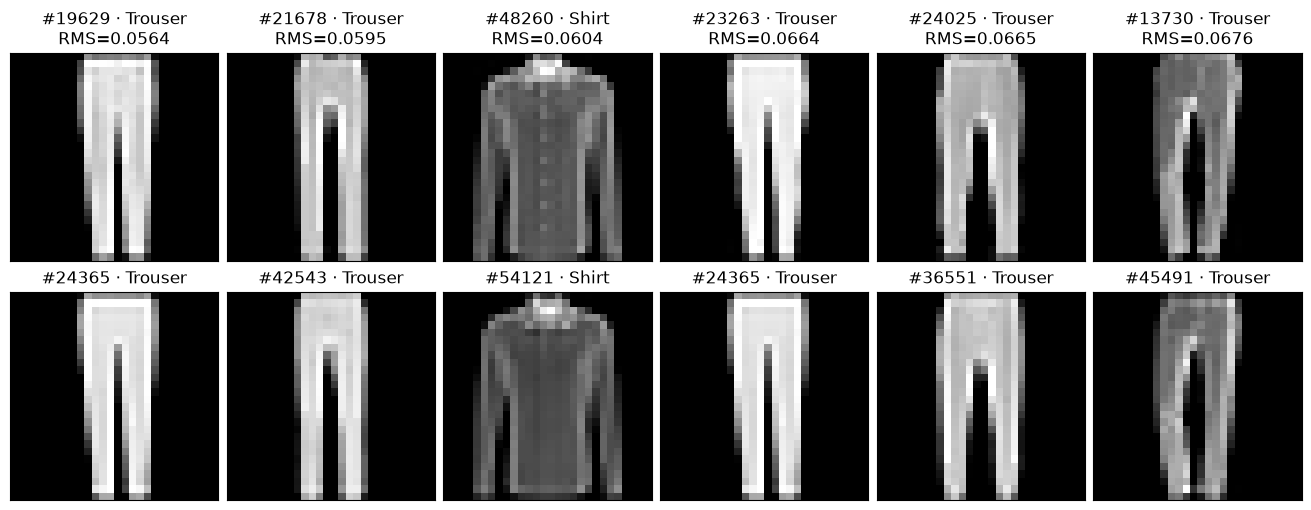

**Observed:** the smallest non-identical candidate distance is 0.0564 among 2,000 unique sampled images. Pixel similarity does not establish shared product identity.

In [21]:
# Keep one representative per hash before querying, excluding exact repeats by construction.
_, first_occurrence = np.unique(image_hashes[eda_sample_idx], return_index=True)
unique_positions = np.sort(first_occurrence)
unique_indices = eda_sample_idx[unique_positions]
unique_flat = eda_sample_flat[unique_positions]
search = NearestNeighbors(n_neighbors=2, algorithm="brute", metric="euclidean", n_jobs=1).fit(unique_flat)
neighbor_distances, neighbor_positions = search.kneighbors(unique_flat)
near_candidates = {}
for local_index, (distances, neighbors) in enumerate(zip(neighbor_distances, neighbor_positions)):
    valid = [(d, j) for d,j in zip(distances, neighbors) if j != local_index]
    distance, neighbor = valid[0]
    a,b = sorted((int(unique_indices[local_index]), int(unique_indices[neighbor])))
    assert a != b and image_hashes[a] != image_hashes[b]
    assert not np.array_equal(X[a], X[b])
    near_candidates[(a,b)] = float(distance / np.sqrt(N_INPUTS))
near_duplicate_pairs = sorted(near_candidates.items(), key=lambda item: (item[1], item[0]))[:6]
fig, axes = plt.subplots(2, 6, figsize=(13, 5), layout="constrained")
for col, ((a,b), distance) in enumerate(near_duplicate_pairs):
    for row,index in enumerate((a,b)):
        axes[row,col].imshow(X[index], cmap="gray", vmin=0, vmax=255)
        axes[row,col].set(title=f"#{index} · {NAMES[y[index]]}" + (f"\nRMS={distance:.4f}" if row == 0 else ""),
                          xticks=[], yticks=[])
plt.show()
np.savez_compressed(EDA_DIR / "neighbor_pairs.npz",
    cross_class_indices=np.array([pair for pair,distance in cross_neighbor_pairs]),
    cross_class_distance=np.array([distance for pair,distance in cross_neighbor_pairs]),
    near_duplicate_indices=np.array([pair for pair,distance in near_duplicate_pairs]),
    near_duplicate_distance=np.array([distance for pair,distance in near_duplicate_pairs]))
display(Markdown(f'**Observed:** the smallest non-identical candidate distance is {near_duplicate_pairs[0][1]:.4f} among {len(unique_indices):,} unique sampled images. Pixel similarity does not establish shared product identity.'))


### 10.6 PCA: retained variance and reconstruction

Fit [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) on a balanced training sample. Compare reconstruction ranks 8–64. Clip displayed images to [0,1]; calculate MSE before clipping.

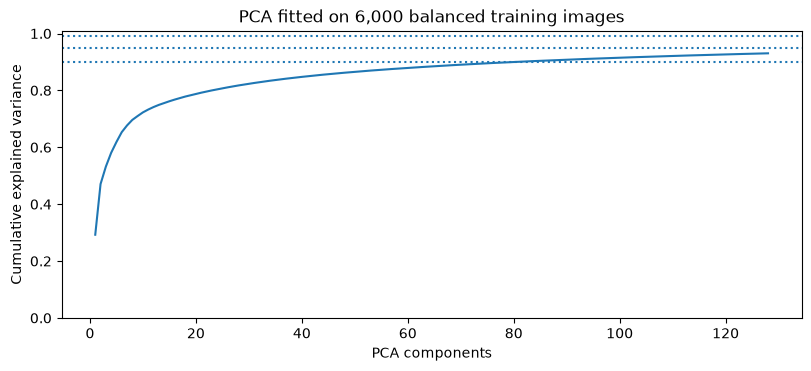

,Variance target,Components within computed range
0,90%,81
1,95%,Not reached by 128
2,99%,Not reached by 128


**Observed:** the first two components explain 47.1%; 128 explain 93.0% of variation in the PCA fitting sample.

In [22]:
from sklearn.decomposition import PCA
from threadpoolctl import threadpool_limits

pca_indices = balanced_training_sample(PCA_PER_CLASS, EDA_SEED + 2)
pca_fit_pixels = X[pca_indices].reshape(len(pca_indices), -1).astype(np.float32) / 255
pca = PCA(n_components=PCA_COMPONENTS, svd_solver="randomized", random_state=EDA_SEED, whiten=False)
with threadpool_limits(limits=1):
    pca.fit(pca_fit_pixels)
pca_scores = pca.transform(eda_sample_flat)
explained = np.cumsum(pca.explained_variance_ratio_)
variance_targets = {}
for target in [.90, .95, .99]:
    matches = np.flatnonzero(explained >= target)
    variance_targets[str(target)] = int(matches[0] + 1) if len(matches) else None
np.save(EDA_DIR / "pca_fit_indices.npy", pca_indices)
np.savez_compressed(EDA_DIR / "pca.npz", mean=pca.mean_, components=pca.components_,
                    explained_variance=pca.explained_variance_, explained_ratio=pca.explained_variance_ratio_,
                    projection_indices=eda_sample_idx, projection_scores=pca_scores)
fig, ax = plt.subplots(figsize=(8, 3.6), layout="constrained")
ax.plot(np.arange(1, len(explained)+1), explained)
for target in [.90, .95, .99]:
    ax.axhline(target, linestyle=":")
ax.set(xlabel="PCA components", ylabel="Cumulative explained variance", ylim=(0,1.01),
       title=f"PCA fitted on {len(pca_indices):,} balanced training images")
plt.show()
table(["Variance target", "Components within computed range"],
      [[f"{float(target):.0%}", rank if rank is not None else f"Not reached by {PCA_COMPONENTS}"]
       for target,rank in variance_targets.items()])
display(Markdown(f'**Observed:** the first two components explain {explained[1]:.1%}; {PCA_COMPONENTS} explain {explained[-1]:.1%} of variation in the PCA fitting sample.'))


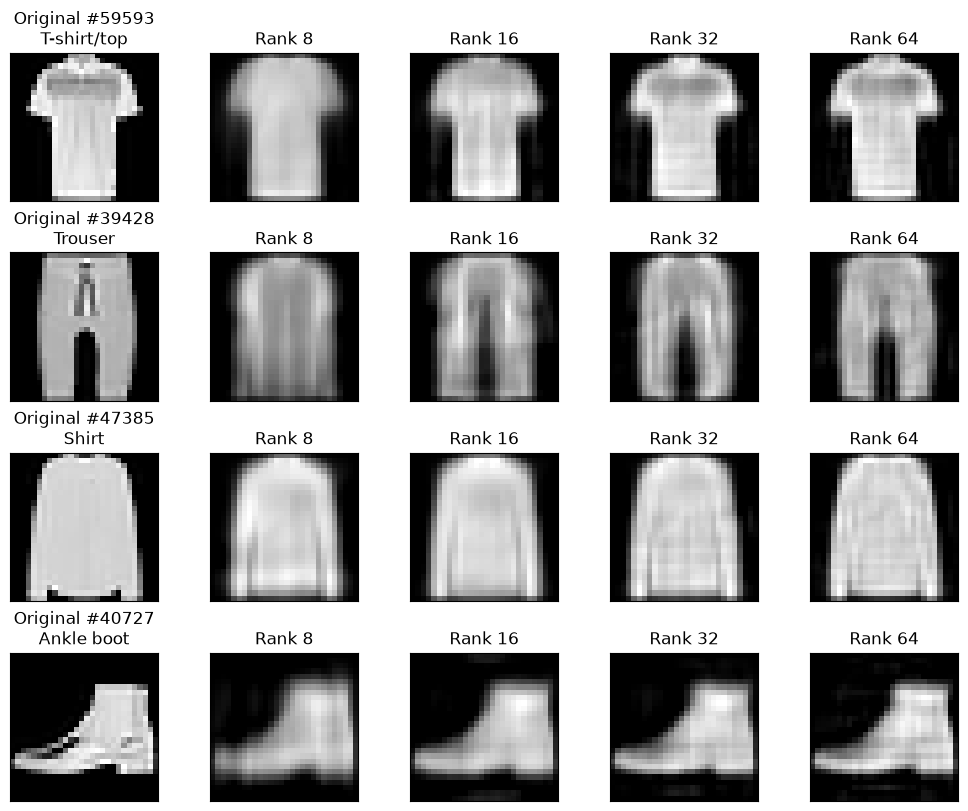

,Rank,MSE on balanced training view sample
0,8,0.02689
1,16,0.02054
2,32,0.01532
3,64,0.01052


**Observed:** reconstruction MSE drops from 0.02689 at rank 8 to 0.01052 at rank 64.

In [23]:
reconstruction_ranks = [8, 16, 32, 64]
reconstruction_classes = [0, 1, 6, 9]
reconstruction_positions = [int(np.flatnonzero(eda_sample_y == c)[0]) for c in reconstruction_classes]
reconstruction_mse = {}
fig, axes = plt.subplots(len(reconstruction_positions), 5, figsize=(10, 8), layout="constrained")
for row, position in enumerate(reconstruction_positions):
    index = int(eda_sample_idx[position])
    axes[row,0].imshow(X[index], cmap="gray", vmin=0, vmax=255)
    axes[row,0].set_title(f"Original #{index}\n{NAMES[y[index]]}")
    for col,rank in enumerate(reconstruction_ranks, 1):
        recovered = pca_scores[position,:rank] @ pca.components_[:rank] + pca.mean_
        axes[row,col].imshow(np.clip(recovered.reshape(28,28),0,1), cmap="gray", vmin=0, vmax=1)
        axes[row,col].set_title(f"Rank {rank}")
    for ax in axes[row]:
        ax.set(xticks=[], yticks=[])
for rank in reconstruction_ranks:
    recovered = pca_scores[:,:rank] @ pca.components_[:rank] + pca.mean_
    reconstruction_mse[rank] = float(np.mean((eda_sample_flat - recovered) ** 2))
plt.show()
table(["Rank", "MSE on balanced training view sample"],
      [[rank, f"{error:.5f}"] for rank,error in reconstruction_mse.items()])
display(Markdown(f'**Observed:** reconstruction MSE drops from {reconstruction_mse[8]:.5f} at rank 8 to {reconstruction_mse[64]:.5f} at rank 64.'))


### 10.7 Two views of the same training sample

Compare PCA and [t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) on the same sample; t-SNE uses 50 PCA coordinates. Interpret local neighborhoods cautiously: plot gaps do not establish class separability.

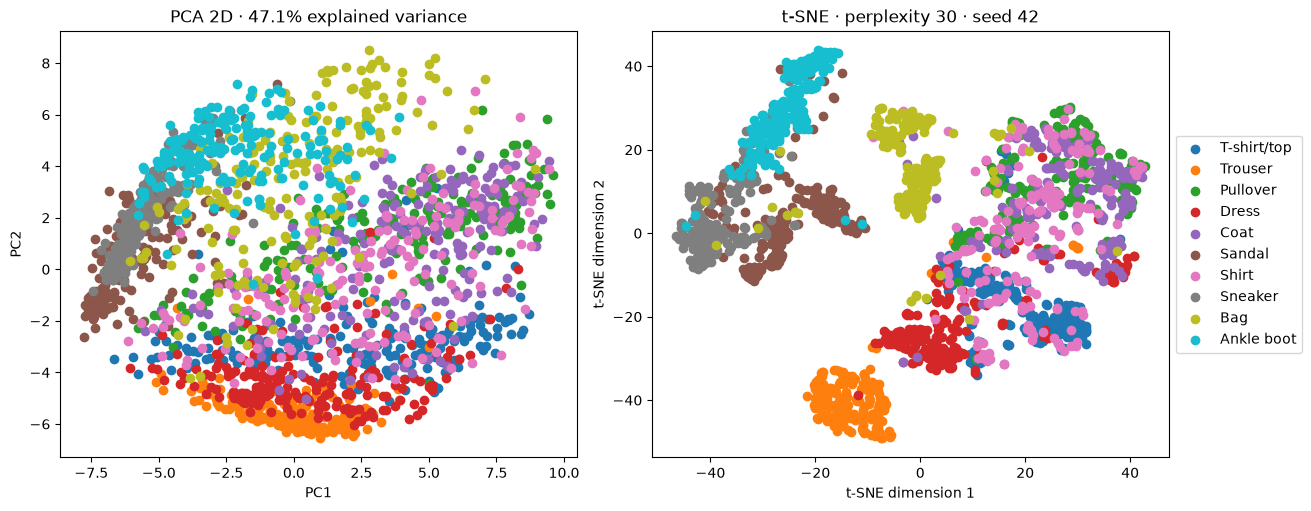

,Displayed coordinates,Mean same-label fraction among 10 neighbors
0,PCA 2D,44.5%
1,t-SNE 2D,70.8%


**Observed structure:** same-label neighbor agreement is 44.5% in PCA 2D and 70.8% in t-SNE 2D. Shirt has the lowest class-average agreement in t-SNE (34.9%). This is local label mixing, not prediction accuracy.

**Observed:** t-SNE completed 750 iterations in 6.1s with final KL objective 0.881. KL measures embedding fit.

In [24]:
from sklearn.manifold import TSNE

tsne_settings = {"n_components": 2, "perplexity": TSNE_PERPLEXITY,
                 "learning_rate": "auto", "max_iter": TSNE_ITERATIONS,
                 "init": "pca", "random_state": EDA_SEED,
                 "method": "barnes_hut", "angle": .5, "n_jobs": 1}
tsne = TSNE(**tsne_settings)
started = time.perf_counter()
with threadpool_limits(limits=1):
    tsne_coordinates = tsne.fit_transform(pca_scores[:,:50])
tsne_seconds = time.perf_counter() - started
np.savez_compressed(EDA_DIR / "embeddings.npz", indices=eda_sample_idx,
                    labels=eda_sample_y, pca=pca_scores[:,:2], tsne=tsne_coordinates)
fig, axes = plt.subplots(1,2,figsize=(13,5), layout="constrained")
for c in range(N_CLASSES):
    selected = eda_sample_y == c
    axes[0].scatter(pca_scores[selected,0], pca_scores[selected,1], label=NAMES[c])
    axes[1].scatter(tsne_coordinates[selected,0], tsne_coordinates[selected,1], label=NAMES[c])
axes[0].set(title=f"PCA 2D · {explained[1]:.1%} explained variance", xlabel="PC1", ylabel="PC2")
axes[1].set(title=f"t-SNE · perplexity {TSNE_PERPLEXITY} · seed {EDA_SEED}", xlabel="t-SNE dimension 1", ylabel="t-SNE dimension 2")
axes[1].legend(loc="center left", bbox_to_anchor=(1, .5))
plt.show()
# Descriptive label agreement among ten neighbors in each displayed geometry.
# Omitting query X excludes each fitted sample's own identity.
projection_neighbor_agreement = {}
projection_class_agreement = {}
for name, coordinates in [("PCA 2D", pca_scores[:,:2]), ("t-SNE 2D", tsne_coordinates)]:
    neighbors = NearestNeighbors(n_neighbors=10, n_jobs=1).fit(coordinates).kneighbors(return_distance=False)
    agreement = (eda_sample_y[neighbors] == eda_sample_y[:,None]).mean(axis=1)
    projection_neighbor_agreement[name] = float(agreement.mean())
    projection_class_agreement[name] = [float(agreement[eda_sample_y == c].mean()) for c in range(N_CLASSES)]
table(["Displayed coordinates", "Mean same-label fraction among 10 neighbors"],
      [[name, f"{value:.1%}"] for name,value in projection_neighbor_agreement.items()])
lowest_tsne_class = int(np.argmin(projection_class_agreement["t-SNE 2D"]))
display(Markdown(f"**Observed structure:** same-label neighbor agreement is {projection_neighbor_agreement['PCA 2D']:.1%} in PCA 2D and {projection_neighbor_agreement['t-SNE 2D']:.1%} in t-SNE 2D. {NAMES[lowest_tsne_class]} has the lowest class-average agreement in t-SNE ({projection_class_agreement['t-SNE 2D'][lowest_tsne_class]:.1%}). This is local label mixing, not prediction accuracy."))
display(Markdown(f'**Observed:** t-SNE completed {tsne.n_iter_ + 1} iterations in {tsne_seconds:.1f}s with final KL objective {tsne.kl_divergence_:.3f}. KL measures embedding fit.'))


### 10.8 Evidence → baseline decisions

In [25]:
train_class_counts = np.bincount(eda_labels, minlength=N_CLASSES)
imbalance = float(train_class_counts.max() / train_class_counts.min())
table(["Measured evidence", "Decision or hypothesis", "Limit"], [
    [f"Training class-count ratio {imbalance:.3f}", "Start with unweighted cross-entropy; report macro-F1 too",
     "Equal counts do not imply equal difficulty"],
    [f"Every input is {X.shape[1]} × {X.shape[2]}", "Keep native resolution and all flattened coordinates",
     "Flattening does not encode spatial locality"],
    [f"Training mean {float(mean):.5f}, std {float(std):.5f}", "Share training-fitted normalization across models",
     "Validation and test statistics do not fit this transform"],
    [f"{zero_fraction:.1%} zero pixels; {near_constant_pixels} low-variance locations", "Retain a simple dense baseline",
     "Feature variance is not predictive importance"],
    [f"Closest means: {NAMES[closest_a]} / {NAMES[closest_b]}", "Inspect related clothing errors after training",
     "Pixel proximity is a hypothesis about difficulty"],
    [f"{quality['border_touch'].mean():.1%} foreground border touch", "Consider spatial structure in a later CNN experiment",
     "Threshold/crop effects; a CNN benefit is untested here"],
    [f"{exact_overlap['Training / Validation']['shared_hashes']} shared exact training/validation images",
     "Keep the fixed baseline split; report the audit", "Related products can have different pixel arrays"],
    [f"Two PCs retain {explained[1]:.1%} variance", "Train on full pixels, use projections for inspection",
     "2D separation does not establish predictive performance"]])

eda_summary = {"seed": EDA_SEED, "zero_fraction": zero_fraction,
    "zero_variance_pixels": zero_variance_pixels, "near_constant_pixels": near_constant_pixels,
    "foreground_threshold": FOREGROUND_THRESHOLD, "threshold_sensitivity": sensitivity,
    "tail_indices": tail_indices, "centroid_exemplars": centroid_exemplars,
    "class_spread": class_spread, "closest_centroid_pairs": closest_centroid_pairs,
    "centroid_distance": centroid_distance.tolist(), "within_median": float(np.median(within_dist)),
    "between_median": float(np.median(between_dist)), "exact_overlap": exact_overlap,
    "duplicate_groups": len(duplicate_groups), "conflicting_duplicate_groups": len(conflict_groups),
    "pca_variance_targets": variance_targets, "pca_cumulative_variance": explained.tolist(),
    "reconstruction_mse": reconstruction_mse, "tsne_settings": tsne_settings,
    "tsne_seconds": tsne_seconds, "tsne_final_kl": float(tsne.kl_divergence_),
    "projection_neighbor_agreement": projection_neighbor_agreement,
    "projection_class_agreement": projection_class_agreement}
eda_settings = {"seed": EDA_SEED, "foreground_threshold": FOREGROUND_THRESHOLD,
    "near_constant_variance": NEAR_CONSTANT_VARIANCE, "pca_per_class": PCA_PER_CLASS,
    "view_per_class": VIEW_PER_CLASS, "pca_components": PCA_COMPONENTS,
    "pca_solver": "randomized", "pca_whiten": False, "pca_seed": EDA_SEED,
    "pca_sample_seed": EDA_SEED+2, "pair_seed": EDA_SEED+1, "pairs_per_anchor_class": 1000,
    "distance": "RMS scaled uint8 pixels / 255", "tsne_input_components": 50,
    "tsne": tsne_settings, "training_only_fit_and_selection": True}
(EDA_DIR / "summary.json").write_text(json.dumps(eda_summary, indent=2))
(EDA_DIR / "settings.json").write_text(json.dumps(eda_settings, indent=2))
np.savez_compressed(EDA_DIR / "pixel_and_class_structure.npz", pixel_mean=pixel_mean,
                    pixel_variance=pixel_variance, class_means=class_means,
                    class_variances=class_variances, centroid_distance=centroid_distance)
assert np.isin(pca_indices, train_idx).all() and np.isin(eda_sample_idx, train_idx).all()
assert not np.isin(pca_indices, val_idx).any() and not np.isin(eda_sample_idx, val_idx).any()
display(Markdown(f"Saved EDA settings, sampled indices, image features, pair identities, duplicate "
                 f"groups and projection arrays to `{EDA_DIR.name}/` in this run."))
# Large temporary arrays are no longer needed by the training section.
del eda_pixels, pca_fit_pixels, class_pixels, recovered

,Measured evidence,Decision or hypothesis,Limit
0,Training class-count ratio 1.000,Start with unweighted cross-entropy; report ma...,Equal counts do not imply equal difficulty
1,Every input is 28 × 28,Keep native resolution and all flattened coord...,Flattening does not encode spatial locality
2,"Training mean 0.28621, std 0.35316",Share training-fitted normalization across models,Validation and test statistics do not fit this...
3,50.2% zero pixels; 11 low-variance locations,Retain a simple dense baseline,Feature variance is not predictive importance
4,Closest means: Pullover / Coat,Inspect related clothing errors after training,Pixel proximity is a hypothesis about difficulty
5,99.4% foreground border touch,Consider spatial structure in a later CNN expe...,Threshold/crop effects; a CNN benefit is untes...
6,0 shared exact training/validation images,Keep the fixed baseline split; report the audit,Related products can have different pixel arrays
7,Two PCs retain 47.1% variance,"Train on full pixels, use projections for insp...",2D separation does not establish predictive pe...


Saved EDA settings, sampled indices, image features, pair identities, duplicate groups and projection arrays to `eda/` in this run.

## 11. Models: nonlinearity and width

Linear maps 784 pixels to ten logits. Each MLP adds a ReLU hidden layer. A dense layer has $ab+b$ parameters. See the [MLP reference](https://d2l.ai/chapter_multilayer-perceptrons/mlp.html).

In [26]:
class Classifier(nn.Module):
    def __init__(self, hidden=()):
        super().__init__()
        layers = [nn.Flatten()]
        previous = N_INPUTS
        for width in hidden:
            layers.extend([nn.Linear(previous, width), nn.ReLU()])
            previous = width
        layers.append(nn.Linear(previous, N_CLASSES))
        self.layers = nn.Sequential(*layers)

    def forward(self, images):
        return self.layers(images)

MODEL_SPECS = [('Linear', []), ('MLP64', [64]), ('MLP256', [256])]
architecture_rows = []
for name, hidden in MODEL_SPECS:
    example_model = Classifier(hidden)
    dims = [N_INPUTS, *hidden, N_CLASSES]
    derived = sum(a * b + b for a, b in zip(dims, dims[1:]))
    actual = sum(p.numel() for p in example_model.parameters())
    assert actual == derived
    assert example_model(xb).shape == (len(xb), N_CLASSES)
    architecture_rows.append([name, ' → '.join(map(str, dims)),
                              ' + '.join(f'{a}×{b}+{b}' for a, b in zip(dims, dims[1:])),
                              f'{actual:,}'])
table(['Model', 'Layer widths', 'Parameter calculation', 'Parameters'], architecture_rows)

,Model,Layer widths,Parameter calculation,Parameters
0,Linear,784 → 10,784×10+10,"7,850"
1,MLP64,784 → 64 → 10,784×64+64 + 64×10+10,"50,890"
2,MLP256,784 → 256 → 10,784×256+256 + 256×10+10,"203,530"


### One batch, forward and backward

Pass logits directly to cross-entropy. `backward()` computes gradients; `step()` updates weights. This demonstration uses a separate model.

In [27]:
torch.manual_seed(42)
demo = Classifier([64]).to(DEVICE)
demo_optimizer = torch.optim.Adam(demo.parameters(), lr=0.001)
features = xb.to(DEVICE)
shape_rows = [['Input', str(tuple(features.shape))]]
for layer in demo.layers:
    features = layer(features)
    shape_rows.append([layer.__class__.__name__, str(tuple(features.shape))])
demo_loss = nn.CrossEntropyLoss()(features, yb.to(DEVICE))
demo_optimizer.zero_grad(set_to_none=True)
before = demo.layers[1].weight.detach().clone()
demo_loss.backward()
grad_norm = float(demo.layers[1].weight.grad.norm())
assert torch.equal(before, demo.layers[1].weight.detach())
demo_optimizer.step()
change = float((demo.layers[1].weight.detach() - before).norm())
table(['Stage', 'Tensor shape'], shape_rows)
display(pd.Series({'Batch cross-entropy': f'{demo_loss.item():.4f}',
       'First-layer gradient norm': f'{grad_norm:.4f}',
       'Weight change after step': f'{change:.4f}'}, name="Value").to_frame())
del demo, demo_optimizer, features, before, demo_loss

,Stage,Tensor shape
0,Input,"(128, 1, 28, 28)"
1,Flatten,"(128, 784)"
2,Linear,"(128, 64)"
3,ReLU,"(128, 64)"
4,Linear,"(128, 10)"


,Value
Batch cross-entropy,2.3547
First-layer gradient norm,1.8986
Weight change after step,0.2240


## 12. Experiments and training

- Training seeds: 42, 7, 123. Set `RUN_REPEATS=False` to use only 42.
- Select highest validation macro-F1; keep earliest ties.
- Stop after four unimproved epochs or 16 total.

Validation selects checkpoints and compares models, so scores are development estimates.

In [28]:
BATCH_SIZE = 128
MAX_EPOCHS = 16
PATIENCE = 4
LEARNING_RATE = 0.001
CLIP_NORM = 5.0
PRIMARY_SEED = 42
TRAINING_SEEDS = [42, 7, 123]
RUN_REPEATS = True
INFERENCE_WARMUP = 1
INFERENCE_REPEATS = 3
assert BATCH_SIZE > 0 and MAX_EPOCHS > 0 and PATIENCE > 0
assert LEARNING_RATE > 0 and CLIP_NORM > 0
assert PRIMARY_SEED in TRAINING_SEEDS and len(set(TRAINING_SEEDS)) == len(TRAINING_SEEDS)
EXPERIMENTS = [dict(name=name, hidden=hidden, seed=PRIMARY_SEED,
                    lr=LEARNING_RATE, dropout=0.0, weight_decay=0.0)
               for name, hidden in MODEL_SPECS]
table(['Setting', 'Value'], [
    ['Optimizer / learning rate', f'Adam / {LEARNING_RATE}'],
    ['Batch size / max epochs / patience', f'{BATCH_SIZE} / {MAX_EPOCHS} / {PATIENCE}'],
    ['Regularization / augmentation', 'No weight decay, dropout, scheduler or augmentation'],
    ['Gradient norm clipping', str(CLIP_NORM)],
    ['Device / CPU threads', f'{DEVICE} / {torch.get_num_threads()}'],
    ['Training seeds', str(TRAINING_SEEDS if RUN_REPEATS else [PRIMARY_SEED])],
    ['Checkpoint selection', 'Highest validation macro-F1; earliest tie'],
])

,Setting,Value
0,Optimizer / learning rate,Adam / 0.001
1,Batch size / max epochs / patience,128 / 16 / 4
2,Regularization / augmentation,"No weight decay, dropout, scheduler or augment..."
3,Gradient norm clipping,5.0
4,Device / CPU threads,cpu / 1
5,Training seeds,"[42, 7, 123]"
6,Checkpoint selection,Highest validation macro-F1; earliest tie


### The loop

Training updates weights; validation disables gradients. Weight epoch loss by batch size. Measure the train/validation gap at the same selected checkpoint.

In [29]:
def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    loss_fn = nn.CrossEntropyLoss()
    total_loss, count = 0.0, 0
    labels, predictions = [], []
    with torch.set_grad_enabled(training):
        for images, targets in loader:
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            if training:
                optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = loss_fn(logits, targets)
            if not torch.isfinite(loss):
                raise FloatingPointError('Non-finite loss; check inputs and learning rate')
            if training:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM, error_if_nonfinite=True)
                optimizer.step()
            total_loss += loss.item() * len(targets)
            count += len(targets)
            labels.extend(targets.cpu().tolist())
            predictions.extend(logits.detach().argmax(1).cpu().tolist())
    assert count == len(loader.dataset), 'A batch was dropped or repeated'
    metrics = {'loss': total_loss / count,
               'accuracy': float(accuracy_score(labels, predictions)),
               'macro_f1': float(f1_score(labels, predictions, labels=list(range(N_CLASSES)),
                                          average='macro', zero_division=0))}
    return metrics, np.asarray(labels, dtype=np.int64), np.asarray(predictions, dtype=np.int64)

In [30]:
def fit(config):
    assert config['dropout'] == 0.0 and config['weight_decay'] == 0.0, 'This is the unregularized baseline'
    random.seed(config['seed'])
    np.random.seed(config['seed'])
    torch.manual_seed(config['seed'])
    train_loader, validation_loader = make_loaders(BATCH_SIZE, config['seed'])
    model = Classifier(config['hidden']).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'], weight_decay=0.0)
    history, best_state, best_f1, best_epoch = [], None, -1.0, 0
    start = time.perf_counter()
    for epoch in range(1, MAX_EPOCHS + 1):
        train_metrics, _, _ = run_epoch(model, train_loader, optimizer)
        val_metrics, _, _ = run_epoch(model, validation_loader)
        history.append(dict(epoch=epoch, train=train_metrics, validation=val_metrics))
        if val_metrics['macro_f1'] > best_f1:
            best_f1, best_epoch = val_metrics['macro_f1'], epoch
            best_state = copy.deepcopy(model.state_dict())
        if epoch - best_epoch >= PATIENCE:
            break
    fit_seconds = time.perf_counter() - start
    model.load_state_dict(best_state)
    before_eval = copy.deepcopy(model.state_dict())
    metrics, labels, predictions = run_epoch(model, validation_loader)
    np.testing.assert_array_equal(labels, y[val_idx])
    assert metrics['macro_f1'] == best_f1
    assert all(torch.equal(value, model.state_dict()[key]) for key, value in before_eval.items())
    fixed_train = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    train_metrics, _, _ = run_epoch(model, fixed_train)
    durations = []
    model.eval()
    with torch.inference_mode():
        for repeat in range(INFERENCE_WARMUP + INFERENCE_REPEATS):
            start = time.perf_counter()
            for images, _ in validation_loader:
                model(images.to(DEVICE)).argmax(1)
            if repeat >= INFERENCE_WARMUP:
                durations.append(time.perf_counter() - start)
    return dict(config=copy.deepcopy(config), model=model, state=best_state, history=history,
                best_epoch=best_epoch, stopped_epoch=epoch, validation=metrics,
                train_at_checkpoint=train_metrics, labels=labels, predictions=predictions,
                parameters=sum(p.numel() for p in model.parameters()), fit_seconds=fit_seconds,
                inference_ms=float(np.median(durations) * 1000 / len(val_data)),
                inference_durations_seconds=durations)

### Save each completed run

Save settings, histories, predictions and inference checkpoints in a new batch directory.

CPU timing: fit includes validation/checkpoint copies. Inference includes loading batches through argmax: one warm-up, then median of three passes per image; excludes model loading and metrics.

In [31]:
import platform
import sklearn
import matplotlib
from sklearn.metrics import precision_recall_fscore_support

def array_digest(values):
    return hashlib.sha256(np.ascontiguousarray(values).tobytes()).hexdigest()

def start_training_batch():
    folder = new_numbered_directory(RUN_DIR, 'training', first_name='training')
    protocol = dict(
        run_id=RUN_DIR.name, batch_id=folder.name,
        created_utc=datetime.now(timezone.utc).isoformat(),
        split_seed=SPLIT_SEED, validation_fraction=VAL_FRACTION,
        counts=dict(train=len(train_idx), validation=len(val_idx), test=len(y_test)),
        split_hashes=dict(train=array_digest(train_idx), validation=array_digest(val_idx)),
        split_index_dtype=str(train_idx.dtype), normalization=dict(mean=mean, std=std),
        data_files=inventory, class_names=NAMES, batch_size=BATCH_SIZE,
        max_epochs=MAX_EPOCHS, patience=PATIENCE, learning_rate=LEARNING_RATE,
        clip_norm=CLIP_NORM, checkpoint_metric='validation macro_f1; earliest exact tie',
        dropout=0.0, weight_decay=0.0, scheduler=None, augmentation=None,
        primary_seed=PRIMARY_SEED, training_seeds=TRAINING_SEEDS if RUN_REPEATS else [PRIMARY_SEED],
        repeats_enabled=RUN_REPEATS, device=str(DEVICE), cpu_threads=torch.get_num_threads(),
        deterministic_algorithms=torch.are_deterministic_algorithms_enabled(),
        environment=dict(python=sys.version.split()[0], torch=str(torch.__version__),
                         numpy=np.__version__, sklearn=sklearn.__version__,
                         matplotlib=matplotlib.__version__, platform=platform.platform(),
                         pandas=version('pandas'), ipython=version('ipython'),
                         threadpoolctl=version('threadpoolctl'), machine=platform.machine()),
        notebook_source_sha256=hashlib.sha256(json.dumps(
            [(c['cell_type'], ''.join(c['source'])) for c in json.loads(NOTEBOOK_PATH.read_text())['cells']],
            ensure_ascii=False).encode()).hexdigest(),
        timing=dict(fit='Epoch training, validation and best-weight copies',
                    inference='DataLoader + device transfer + forward + argmax; no metrics',
                    warmup=INFERENCE_WARMUP, measured_passes=INFERENCE_REPEATS,
                    aggregate='median duration / validation image count'),
        official_test_evaluated=False)
    (folder / 'protocol.json').write_text(json.dumps(protocol, indent=2) + '\n')
    np.savez_compressed(folder / 'split_indices.npz', train=train_idx, validation=val_idx)
    return folder, protocol

def serializable_result(result):
    return {k: v for k, v in result.items()
            if k not in ('model', 'state', 'labels', 'predictions')}

def save_result(result, batch_folder, protocol):
    config = result['config']
    folder = batch_folder / f"{config['name']}_seed{config['seed']}"
    folder.mkdir(exist_ok=False)
    result['artifact_folder'] = folder.name
    record = serializable_result(result)
    (folder / 'results.json').write_text(json.dumps(record, indent=2) + '\n')
    np.savez_compressed(folder / 'validation_predictions.npz', indices=val_idx,
                        labels=result['labels'], predictions=result['predictions'])
    matrix = confusion_matrix(result['labels'], result['predictions'], labels=range(N_CLASSES))
    np.savetxt(folder / 'confusion_counts.csv', matrix, delimiter=',', fmt='%d')
    class_report = classification_report(result['labels'], result['predictions'],
        labels=list(range(N_CLASSES)), target_names=NAMES, zero_division=0, output_dict=True)
    (folder / 'class_metrics.json').write_text(json.dumps(class_report, indent=2) + '\n')
    torch.save(dict(model_state=result['state'], config=config, protocol=protocol,
                    n_inputs=N_INPUTS, n_classes=N_CLASSES, epoch=result['best_epoch']), folder / 'best.pt')

In [32]:
# Re-run this cell to start a fresh batch; prior training artifacts are never overwritten.
BATCH_DIR, protocol = start_training_batch()
run_configs = [copy.deepcopy(config) for config in EXPERIMENTS]
if RUN_REPEATS:
    run_configs += [dict(config, seed=seed) for seed in TRAINING_SEEDS
                    if seed != PRIMARY_SEED for config in EXPERIMENTS]
all_results = []
for config in run_configs:
    result = fit(config)
    result['role'] = 'main' if config['seed'] == PRIMARY_SEED else 'repeat'
    save_result(result, BATCH_DIR, protocol)
    all_results.append(result)
    (BATCH_DIR / 'results.json').write_text(
        json.dumps([serializable_result(r) for r in all_results], indent=2) + '\n')
    print(f"{config['name']:7} seed {config['seed']:3} | selected {result['best_epoch']:2}/"
          f"{result['stopped_epoch']:2} epochs | val F1 {result['validation']['macro_f1']:.4f} | "
          f"fit {result['fit_seconds']:.1f}s", flush=True)
main_results = [r for r in all_results if r['role'] == 'main']
results = main_results  # Short alias for exploring the primary comparison.
assert len(main_results) == len(MODEL_SPECS)
print('Saved batch:', BATCH_DIR.relative_to(ROOT))
print('Repeat comparison:', 'completed' if RUN_REPEATS else 'disabled; primary runs only')

Linear  seed  42 | selected  3/ 7 epochs | val F1 0.8620 | fit 2.0s
MLP64   seed  42 | selected 14/16 epochs | val F1 0.8988 | fit 5.3s
MLP256  seed  42 | selected 14/16 epochs | val F1 0.9070 | fit 8.3s
Linear  seed   7 | selected 12/16 epochs | val F1 0.8662 | fit 4.3s
MLP64   seed   7 | selected 16/16 epochs | val F1 0.8992 | fit 5.3s
MLP256  seed   7 | selected 16/16 epochs | val F1 0.9067 | fit 8.2s
Linear  seed 123 | selected 12/16 epochs | val F1 0.8666 | fit 4.3s
MLP64   seed 123 | selected 16/16 epochs | val F1 0.8986 | fit 5.3s
MLP256  seed 123 | selected 16/16 epochs | val F1 0.9065 | fit 8.1s
Saved batch: experiments/a1_m1/run_001/training
Repeat comparison: completed


## 13. Results and error analysis

Compare accuracy, macro-F1, parameters and runtime. Macro-F1 weights all ten classes equally.

In [33]:
best = max(main_results, key=lambda r: r['validation']['macro_f1'])
def emphasize(value, is_best):
    return f'**{value}**' if is_best else value
table(['Model', 'Validation accuracy', 'Macro-F1', 'Selected / stopped epoch', 'Fixed-checkpoint gap¹'],
      [[r['config']['name'], emphasize(f"{r['validation']['accuracy']:.2%}",
        r['validation']['accuracy'] == max(x['validation']['accuracy'] for x in main_results)),
        emphasize(f"{r['validation']['macro_f1']:.4f}", r is best), f"{r['best_epoch']} / {r['stopped_epoch']}",
        f"{100 * (r['train_at_checkpoint']['accuracy'] - r['validation']['accuracy']):.2f} pp"]
       for r in main_results])
table(['Model', 'Parameters', 'Fit seconds', 'Inference ms / image'],
      [[r['config']['name'], emphasize(f"{r['parameters']:,}", r['parameters'] == min(x['parameters'] for x in main_results)),
        emphasize(f"{r['fit_seconds']:.2f}", r['fit_seconds'] == min(x['fit_seconds'] for x in main_results)),
        emphasize(f"{r['inference_ms']:.4f}", r['inference_ms'] == min(x['inference_ms'] for x in main_results))]
       for r in main_results])
display(pd.Series({'Best primary macro-F1': f"{best['config']['name']} · {best['validation']['macro_f1']:.4f}",
       'Fewest parameters': min(main_results, key=lambda r: r['parameters'])['config']['name'],
       'Completed model fits': len(all_results)}, name="Value").to_frame())
display(Markdown('¹ Training accuracy minus validation accuracy, evaluated with the same selected weights.'))

,Model,Validation accuracy,Macro-F1,Selected / stopped epoch,Fixed-checkpoint gap¹
0,Linear,86.20%,0.8620,3 / 7,-0.74 pp
1,MLP64,89.90%,0.8988,14 / 16,2.56 pp
2,MLP256,**90.68%**,**0.9070**,14 / 16,3.91 pp


,Model,Parameters,Fit seconds,Inference ms / image
0,Linear,"**7,850**",**2.01**,**0.0022**
1,MLP64,"50,890",5.31,0.0023
2,MLP256,"203,530",8.32,0.0028


,Value
Best primary macro-F1,MLP256 · 0.9070
Fewest parameters,Linear
Completed model fits,9


¹ Training accuracy minus validation accuracy, evaluated with the same selected weights.

### Learning curves and selected checkpoints

Dashed: training during updates. Solid: validation after each epoch. Stars: checkpoints selected by macro-F1.

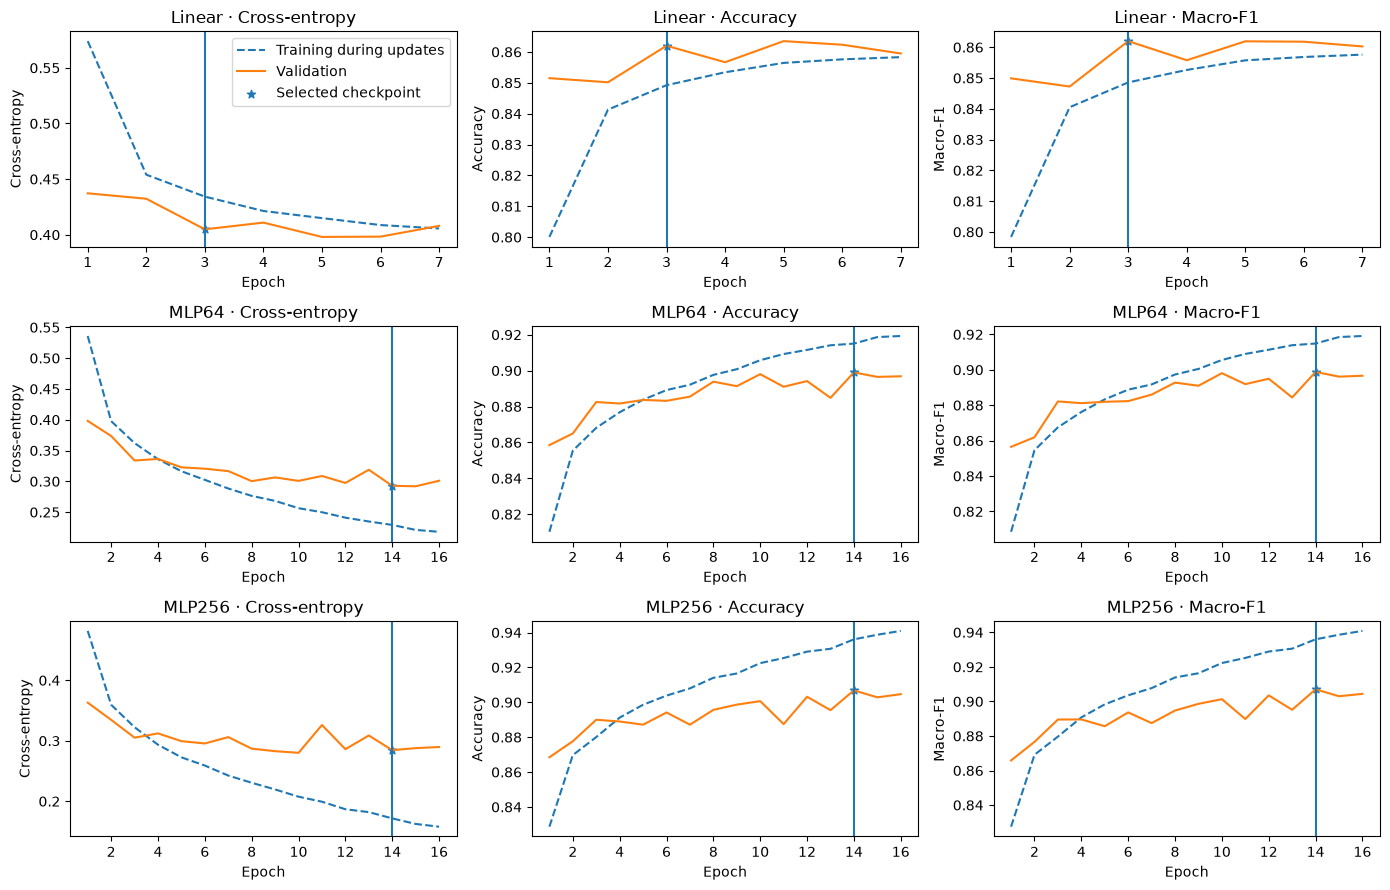

In [34]:
METRICS = [('loss', 'Cross-entropy'), ('accuracy', 'Accuracy'), ('macro_f1', 'Macro-F1')]
fig, axes = plt.subplots(len(main_results), 3, figsize=(14, 9), squeeze=False)
for row, result in enumerate(main_results):
    name = result['config']['name']
    epochs = [h['epoch'] for h in result['history']]
    chosen = result['history'][result['best_epoch'] - 1]
    for ax, (metric, label) in zip(axes[row], METRICS):
        ax.plot(epochs, [h['train'][metric] for h in result['history']], '--', label='Training during updates')
        ax.plot(epochs, [h['validation'][metric] for h in result['history']], label='Validation')
        ax.scatter(result['best_epoch'], chosen['validation'][metric], marker='*', label='Selected checkpoint')
        ax.axvline(result['best_epoch'])
        ax.set(title=f'{name} · {label}', xlabel='Epoch', ylabel=label)

axes[0, 0].legend()
plt.tight_layout(); plt.show()

In [35]:
# Optional live controls; the complete curve grid above remains available without a kernel.
try:
    import ipywidgets as widgets
    curve_model = widgets.Dropdown(options=[r['config']['name'] for r in main_results],description='Model:')
    curve_metric = widgets.Dropdown(options=[('Loss','loss'),('Accuracy','accuracy'),('Macro-F1','macro_f1')],description='Metric:')
    curve_output = widgets.Output()
    def update_curve(change):
        r = next(r for r in main_results if r['config']['name']==curve_model.value)
        metric = curve_metric.value
        with curve_output:
            curve_output.clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(8,3.5))
            epochs = [h['epoch'] for h in r['history']]
            for split, style in [('train','--'),('validation','-')]:
                ax.plot(epochs,[h[split][metric] for h in r['history']],style,label=split)
            ax.axvline(r['best_epoch'],linestyle=':',label='Selected checkpoint')
            ax.set(xlabel='Epoch',ylabel=metric,title=curve_model.value); ax.legend()
            plt.tight_layout(); plt.show()
    curve_model.observe(update_curve,names='value'); curve_metric.observe(update_curve,names='value')
    display(widgets.VBox([widgets.HBox([curve_model,curve_metric]),curve_output]))
except ImportError:
    display(Markdown('Live curve controls need optional ipywidgets; the static curve grid is complete.'))


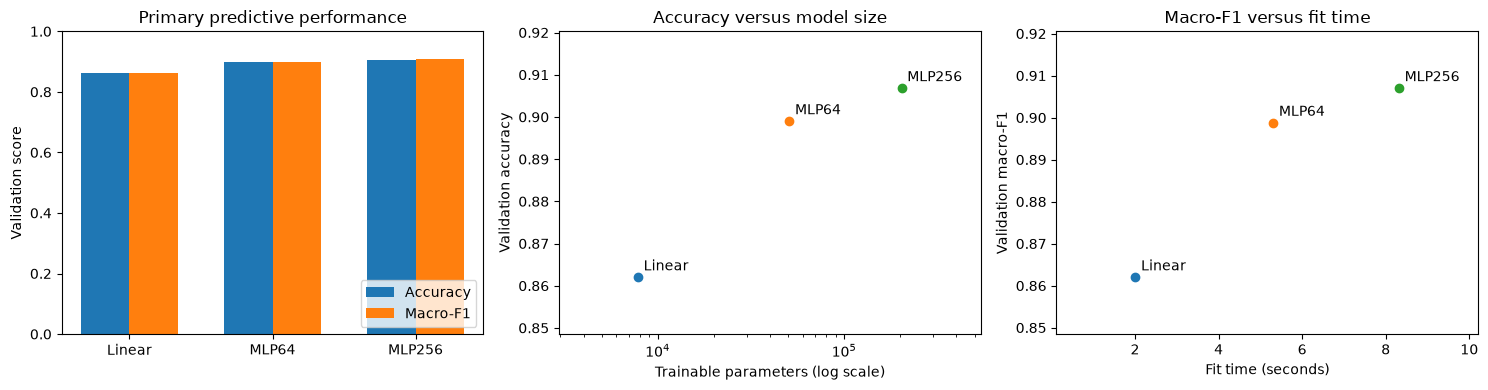

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
positions = np.arange(len(main_results))
for j, (metric, label) in enumerate(METRICS[1:]):
    axes[0].bar(positions + (j - .5) * .34,
                [r['validation'][metric] for r in main_results], width=.34,
                label=label)
axes[0].set_xticks(positions, [r['config']['name'] for r in main_results])
axes[0].set(ylabel='Validation score', ylim=(0, 1), title='Primary predictive performance')
axes[0].legend(loc="lower right")
for result in main_results:
    name = result['config']['name']
    axes[1].scatter(result['parameters'], result['validation']['accuracy'])
    axes[1].annotate(name, (result['parameters'], result['validation']['accuracy']),
                     xytext=(4, 5), textcoords='offset points')
    axes[2].scatter(result['fit_seconds'], result['validation']['macro_f1'])
    axes[2].annotate(name, (result['fit_seconds'], result['validation']['macro_f1']),
                     xytext=(4, 5), textcoords='offset points')
axes[1].set(xscale='log', xlabel='Trainable parameters (log scale)', ylabel='Validation accuracy',
            title='Accuracy versus model size')
axes[2].set(xlabel='Fit time (seconds)', ylabel='Validation macro-F1', title='Macro-F1 versus fit time')
for ax in axes[1:]:
    ax.margins(x=.3, y=.3)

plt.tight_layout(); plt.show()

### Training-seed variability

Dots show runs; bars show mean ± sample SD across three training seeds on one split, not confidence intervals.

,Model,Seed,Accuracy,Macro-F1,Selected epoch
0,Linear,42,86.20%,0.8620,3
1,Linear,7,86.57%,0.8662,12
2,Linear,123,86.63%,0.8666,12
3,MLP64,42,89.90%,0.8988,14
4,MLP64,7,89.83%,0.8992,16
5,MLP64,123,89.88%,0.8986,16
6,MLP256,42,90.68%,0.9070,14
7,MLP256,7,90.60%,0.9067,16
8,MLP256,123,90.67%,0.9065,16


,Model,Runs,Mean accuracy ± sample SD,Mean macro-F1 ± sample SD
0,Linear,3,86.47% ± 0.23 pp,0.8649 ± 0.0025
1,MLP64,3,89.87% ± 0.03 pp,0.8989 ± 0.0003
2,MLP256,3,90.65% ± 0.04 pp,0.9067 ± 0.0003


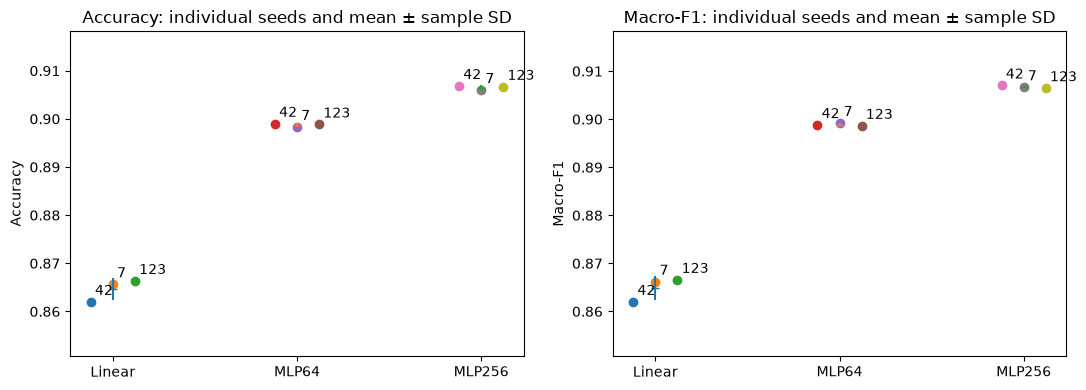

In [37]:
repeat_rows, repeat_summary = [], []
for name, _ in MODEL_SPECS:
    group = [r for r in all_results if r['config']['name'] == name]
    for result in group:
        repeat_rows.append([name, result['config']['seed'],
                            f"{result['validation']['accuracy']:.2%}",
                            f"{result['validation']['macro_f1']:.4f}", result['best_epoch']])
    summary = dict(model=name, n=len(group), seeds=[r['config']['seed'] for r in group])
    for metric in ['accuracy', 'macro_f1']:
        values = np.asarray([r['validation'][metric] for r in group])
        summary[metric + '_mean'] = float(values.mean())
        summary[metric + '_sample_sd'] = float(values.std(ddof=1)) if len(values) > 1 else None
    repeat_summary.append(summary)
table(['Model', 'Seed', 'Accuracy', 'Macro-F1', 'Selected epoch'], repeat_rows)
table(['Model', 'Runs', 'Mean accuracy ± sample SD', 'Mean macro-F1 ± sample SD'],
      [[s['model'], s['n'],
        f"{s['accuracy_mean']:.2%} ± {100 * s['accuracy_sample_sd']:.2f} pp" if s['n'] > 1 else 'SD unavailable',
        f"{s['macro_f1_mean']:.4f} ± {s['macro_f1_sample_sd']:.4f}" if s['n'] > 1 else 'SD unavailable']
       for s in repeat_summary])
(BATCH_DIR / 'repeat_summary.json').write_text(json.dumps(repeat_summary, indent=2) + '\n')
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for j, (metric, label) in enumerate(METRICS[1:]):
    for position, summary in enumerate(repeat_summary):
        group = [r for r in all_results if r['config']['name'] == summary['model']]
        values = [r['validation'][metric] for r in group]
        offsets = np.linspace(-.12, .12, len(group)) if len(group) > 1 else [0]
        for offset, value, result in zip(offsets, values, group):
            axes[j].scatter(position + offset, value)
            axes[j].annotate(str(result['config']['seed']), (position + offset, value),
                             xytext=(3, 5), textcoords='offset points')
        sd = summary[metric + '_sample_sd']
        if sd is not None:
            axes[j].errorbar(position, summary[metric + '_mean'], yerr=sd, fmt='_')
    axes[j].set_xticks(range(len(MODEL_SPECS)), [name for name, _ in MODEL_SPECS])
    axes[j].set(ylabel=label, title=f'{label}: individual seeds and mean ± sample SD')
    axes[j].margins(y=.25)

plt.tight_layout(); plt.show()

### Which classes are confused?

Rows: true classes. Columns: predictions. Numbers show counts; colors show row proportions.

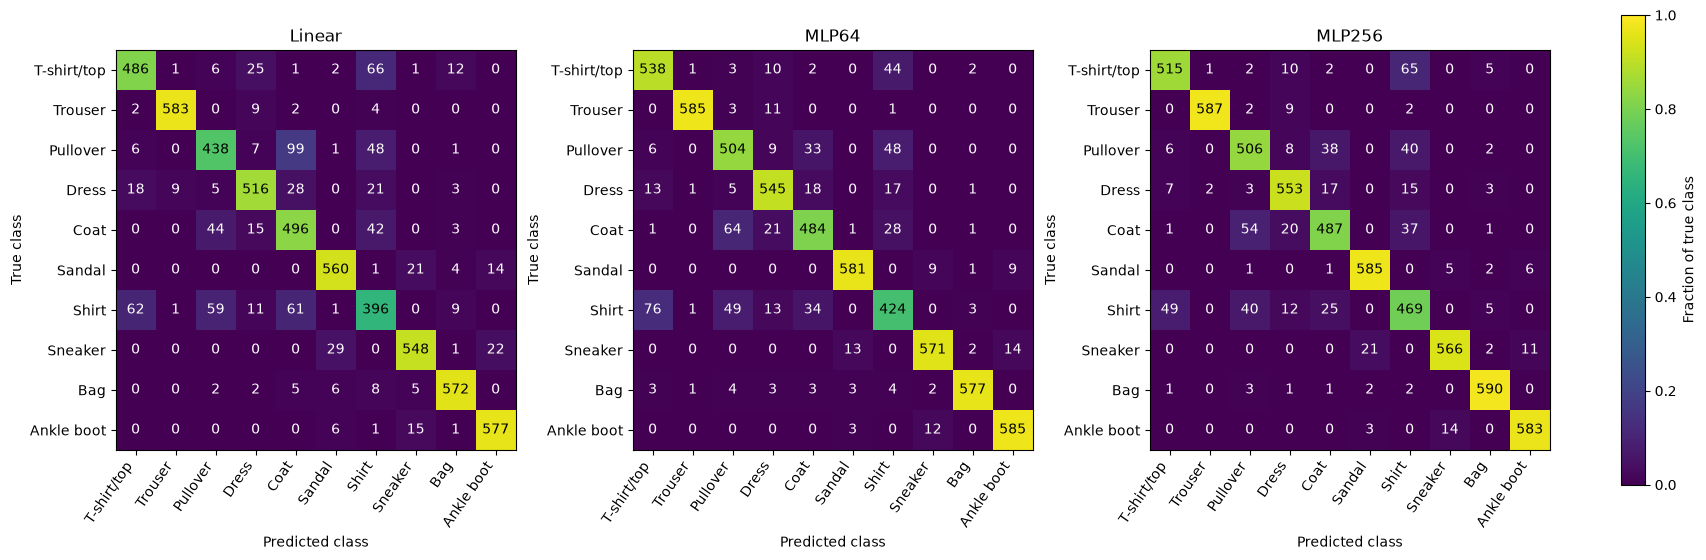

**Linear: per-class validation metrics**

,Class,Precision,Recall,F1,Support
0,T-shirt/top,0.847,0.810,0.828,600
1,Trouser,0.981,0.972,0.977,600
2,Pullover,0.791,0.730,0.759,600
3,Dress,0.882,0.860,0.871,600
4,Coat,0.717,0.827,0.768,600
5,Sandal,0.926,0.933,0.929,600
6,Shirt,0.675,0.660,0.667,600
7,Sneaker,0.929,0.913,0.921,600
8,Bag,0.944,0.953,0.949,600
9,Ankle boot,0.941,0.962,0.951,600


**MLP64: per-class validation metrics**

,Class,Precision,Recall,F1,Support
0,T-shirt/top,0.845,0.897,0.870,600
1,Trouser,0.993,0.975,0.984,600
2,Pullover,0.797,0.840,0.818,600
3,Dress,0.891,0.908,0.899,600
4,Coat,0.843,0.807,0.825,600
5,Sandal,0.967,0.968,0.968,600
6,Shirt,0.749,0.707,0.727,600
7,Sneaker,0.961,0.952,0.956,600
8,Bag,0.983,0.962,0.972,600
9,Ankle boot,0.962,0.975,0.969,600


**MLP256: per-class validation metrics**

,Class,Precision,Recall,F1,Support
0,T-shirt/top,0.889,0.858,0.874,600
1,Trouser,0.995,0.978,0.987,600
2,Pullover,0.828,0.843,0.836,600
3,Dress,0.902,0.922,0.912,600
4,Coat,0.853,0.812,0.832,600
5,Sandal,0.957,0.975,0.966,600
6,Shirt,0.744,0.782,0.763,600
7,Sneaker,0.968,0.943,0.955,600
8,Bag,0.967,0.983,0.975,600
9,Ankle boot,0.972,0.972,0.972,600


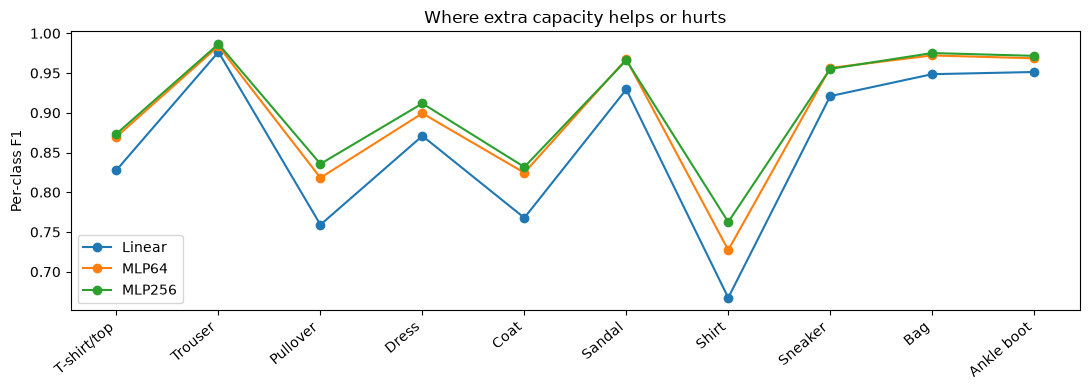

In [38]:
confusions, per_class = {}, {}
fig, axes = plt.subplots(1, len(main_results), figsize=(17, 5.5), squeeze=False, layout="constrained")
for ax, result in zip(axes[0], main_results):
    name = result['config']['name']
    matrix = confusion_matrix(result['labels'], result['predictions'], labels=range(N_CLASSES))
    confusions[name] = matrix
    normalized = matrix / matrix.sum(axis=1, keepdims=True)
    image = ax.imshow(normalized, vmin=0, vmax=1)
    for true in range(N_CLASSES):
        for predicted in range(N_CLASSES):
            ax.text(predicted, true, str(matrix[true, predicted]), ha='center', va='center', color='white' if normalized[true, predicted] < .55 else 'black')
    ax.set_xticks(range(N_CLASSES), NAMES, rotation=55, ha='right')
    ax.set_yticks(range(N_CLASSES), NAMES)
    ax.set(title=name, xlabel='Predicted class', ylabel='True class')
    precision, recall, f1, support = precision_recall_fscore_support(
        result['labels'], result['predictions'], labels=range(N_CLASSES), zero_division=0)
    per_class[name] = dict(precision=precision, recall=recall, f1=f1, support=support)
fig.colorbar(image, ax=axes[0], label='Fraction of true class')
plt.show()
for name, values in per_class.items():
    display(Markdown(f'**{name}: per-class validation metrics**'))
    table(['Class', 'Precision', 'Recall', 'F1', 'Support'],
          [[NAMES[k], f"{values['precision'][k]:.3f}", f"{values['recall'][k]:.3f}",
            f"{values['f1'][k]:.3f}", int(values['support'][k])] for k in range(N_CLASSES)])
fig, ax = plt.subplots(figsize=(11, 4))
for name, values in per_class.items():
    ax.plot(np.arange(N_CLASSES), values['f1'], marker='o', label=name)
ax.set_xticks(range(N_CLASSES), NAMES, rotation=40, ha='right')
ax.set(ylabel='Per-class F1', title='Where extra capacity helps or hurts')
ax.legend()
plt.tight_layout(); plt.show()

In [39]:
# Counts and row-normalized views of the same saved validation predictions.
try:
    import ipywidgets as widgets
    confusion_model = widgets.Dropdown(options=list(confusions),description='Model:')
    confusion_mode = widgets.Dropdown(options=['Row fraction','Count'],description='Values:')
    confusion_output = widgets.Output()
    def update_confusion(change):
        matrix = confusions[confusion_model.value]
        fractions = confusion_mode.value == 'Row fraction'
        values = matrix/matrix.sum(1,keepdims=True) if fractions else matrix
        with confusion_output:
            confusion_output.clear_output(wait=True)
            fig,ax=plt.subplots(figsize=(8,6))
            im=ax.imshow(values,vmin=0,vmax=1 if fractions else None)
            ax.set_xticks(range(N_CLASSES),NAMES,rotation=55,ha='right')
            ax.set_yticks(range(N_CLASSES),NAMES)
            ax.set(xlabel='Predicted class',ylabel='True class',title=confusion_model.value)
            fig.colorbar(im,ax=ax,label=confusion_mode.value)
            plt.tight_layout(); plt.show()
    confusion_model.observe(update_confusion,names='value'); confusion_mode.observe(update_confusion,names='value')
    display(widgets.VBox([widgets.HBox([confusion_model,confusion_mode]),confusion_output]))
except ImportError:
    display(Markdown('Live confusion controls need optional ipywidgets; the static overview is complete.'))


In [40]:
directional_errors = {}
for result in main_results:
    name = result['config']['name']
    matrix = confusions[name]
    off_diagonal = matrix.copy()
    np.fill_diagonal(off_diagonal, 0)
    pairs = []
    for flat_index in np.argsort(-off_diagonal.ravel(), kind='stable'):
        true, predicted = divmod(int(flat_index), N_CLASSES)
        count = int(matrix[true, predicted])
        if count == 0:
            break
        pairs.append(dict(true=true, predicted=predicted, count=count,
                          rate=float(count / matrix[true].sum())))
        if len(pairs) == 5:
            break
    directional_errors[name] = pairs
    display(Markdown(f'**{name}: five most frequent directional errors**'))
    table(['True → predicted', 'Count', 'Rate within true class'],
          [[f"{NAMES[p['true']]} → {NAMES[p['predicted']]}", p['count'], f"{p['rate']:.2%}"]
           for p in pairs])
(BATCH_DIR / 'directional_errors.json').write_text(json.dumps(directional_errors, indent=2) + '\n')

**Linear: five most frequent directional errors**

,True → predicted,Count,Rate within true class
0,Pullover → Coat,99,16.50%
1,T-shirt/top → Shirt,66,11.00%
2,Shirt → T-shirt/top,62,10.33%
3,Shirt → Coat,61,10.17%
4,Shirt → Pullover,59,9.83%


**MLP64: five most frequent directional errors**

,True → predicted,Count,Rate within true class
0,Shirt → T-shirt/top,76,12.67%
1,Coat → Pullover,64,10.67%
2,Shirt → Pullover,49,8.17%
3,Pullover → Shirt,48,8.00%
4,T-shirt/top → Shirt,44,7.33%


**MLP256: five most frequent directional errors**

,True → predicted,Count,Rate within true class
0,T-shirt/top → Shirt,65,10.83%
1,Coat → Pullover,54,9.00%
2,Shirt → T-shirt/top,49,8.17%
3,Pullover → Shirt,40,6.67%
4,Shirt → Pullover,40,6.67%


### Inspect actual predictions

Show the first four correct and incorrect predictions per model in validation order. IDs refer to the original training file.

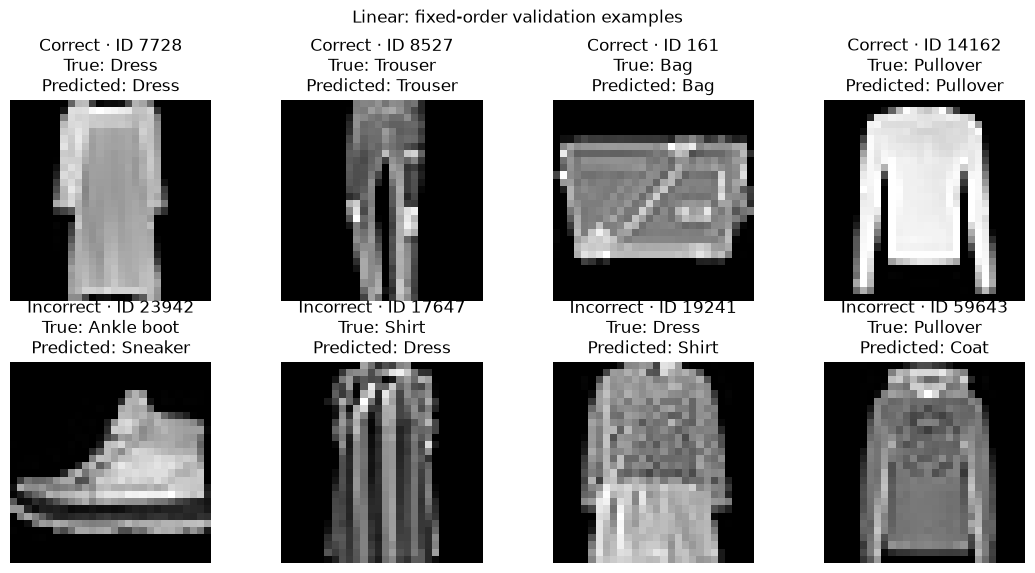

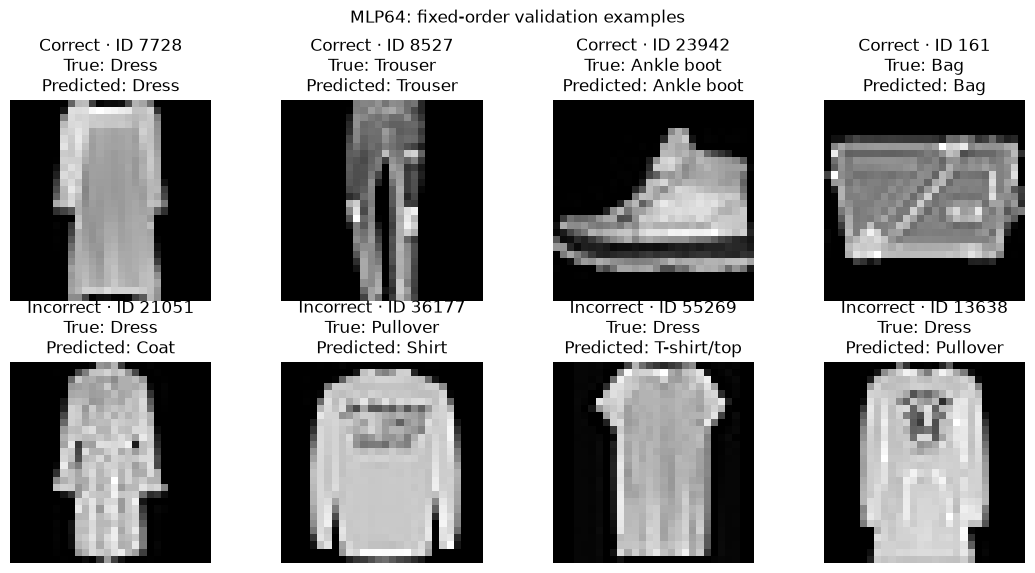

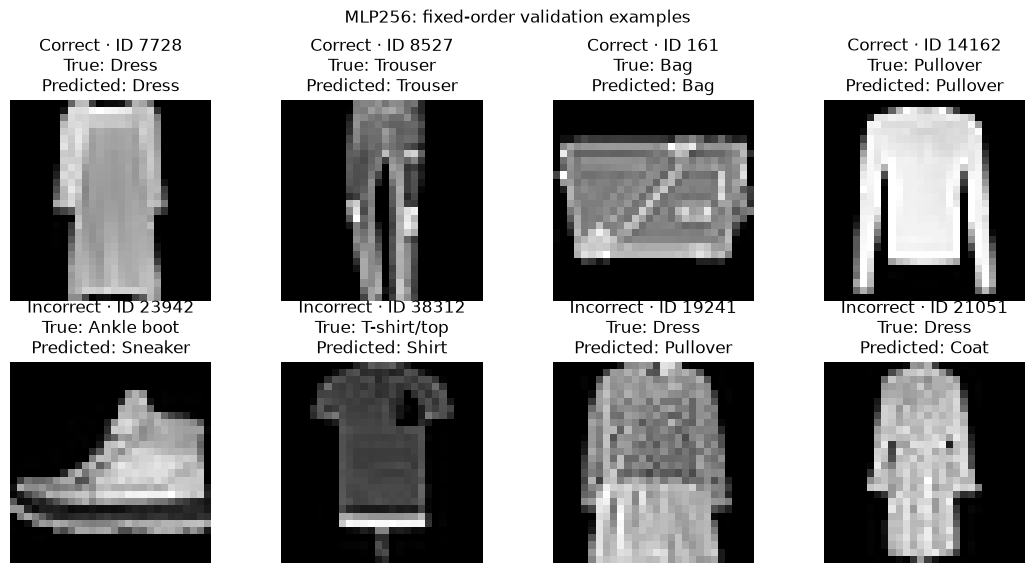

In [41]:
gallery_records = []
for result in main_results:
    name = result['config']['name']
    correct = np.flatnonzero(result['labels'] == result['predictions'])[:4]
    incorrect = np.flatnonzero(result['labels'] != result['predictions'])[:4]
    fig, axes = plt.subplots(2, 4, figsize=(11, 5.8), squeeze=False)
    for ax in axes.flat:
        ax.axis('off')
    for row, (kind, positions) in enumerate([('Correct', correct), ('Incorrect', incorrect)]):
        for ax, position in zip(axes[row], positions):
            index = int(val_idx[position])
            true, predicted = int(result['labels'][position]), int(result['predictions'][position])
            ax.imshow(X[index], cmap='gray', vmin=0, vmax=255)
            ax.set_title(f'{kind} · ID {index}\nTrue: {NAMES[true]}\nPredicted: {NAMES[predicted]}')
            gallery_records.append(dict(model=name, kind=kind, validation_position=int(position),
                                        original_index=index, true=true, predicted=predicted))
    fig.suptitle(name + ': fixed-order validation examples')
    plt.tight_layout(); plt.show()
(BATCH_DIR / 'gallery_selection.json').write_text(json.dumps(gallery_records, indent=2) + '\n')

### Pictured mistakes

Describe the selected model’s errors using foreground measurements and class-centroid distances. These suggest visual overlap, not causal explanations.

In [42]:
pictured_rows = []
display(Markdown(f'Foreground threshold: **{FOREGROUND_THRESHOLD}/255**, shared with EDA. '
                 'Centroid rank is among the nine other classes, using Section 10 pixel RMS distances.'))
for item in gallery_records:
    if item['model'] != best['config']['name'] or item['kind'] != 'Incorrect':
        continue
    raw_image = X[item['original_index']]
    foreground = raw_image > FOREGROUND_THRESHOLD
    rr, cc = np.where(foreground)
    width = int(cc.max() - cc.min() + 1) if len(cc) else 0
    height = int(rr.max() - rr.min() + 1) if len(rr) else 0
    coverage = float(foreground.mean())
    brightness = float(raw_image.mean() / 255)
    true, predicted = item['true'], item['predicted']
    pair = f'{NAMES[true]} → {NAMES[predicted]}'
    matrix = confusions[best['config']['name']]
    other_classes = np.argsort(centroid_distance[true], kind='stable')
    other_classes = other_classes[other_classes != true]
    centroid_rank = int(np.flatnonzero(other_classes == predicted)[0]) + 1
    pictured_rows.append([item['original_index'], pair, f'{width}×{height}',
                          f'{coverage:.1%}', f'{brightness:.3f}', int(matrix[true, predicted]), centroid_rank])
table(['Pictured ID', 'True → predicted', 'Box width×height', 'Coverage', 'Mean intensity',
       'Same-direction errors', 'Centroid distance rank'], pictured_rows)


Foreground threshold: **26/255**, shared with EDA. Centroid rank is among the nine other classes, using Section 10 pixel RMS distances.

,Pictured ID,True → predicted,Box width×height,Coverage,Mean intensity,Same-direction errors,Centroid distance rank
0,23942,Ankle boot → Sneaker,28×20,43.5%,0.254,14,3
1,38312,T-shirt/top → Shirt,20×28,39.3%,0.121,65,1
2,19241,Dress → Pullover,21×28,64.7%,0.381,3,5
3,21051,Dress → Coat,16×28,41.1%,0.291,17,4


## 14. Conclusions and replay

In [43]:
by_name = {r['config']['name']: r for r in main_results}
linear, narrow, wide = [by_name[name] for name in ['Linear', 'MLP64', 'MLP256']]
nonlinear_gain = narrow['validation']['accuracy'] - linear['validation']['accuracy']
width_gain = wide['validation']['accuracy'] - narrow['validation']['accuracy']
width_cost = wide['parameters'] / narrow['parameters']
best_name = best['config']['name']
best_gap = best['train_at_checkpoint']['accuracy'] - best['validation']['accuracy']
worst_class = int(np.argmin(per_class[best_name]['f1']))
leading_error = directional_errors[best_name][0] if directional_errors[best_name] else None
late_loss_change = best['history'][-1]['validation']['loss'] - best['history'][best['best_epoch'] - 1]['validation']['loss']
conclusion_rows = [
    ['Nonlinearity', f"MLP64 changes accuracy by {100 * nonlinear_gain:+.2f} percentage points "
     f"and macro-F1 by {narrow['validation']['macro_f1'] - linear['validation']['macro_f1']:+.4f} versus Linear."],
    ['Width and cost', f"MLP256 changes accuracy by {100 * width_gain:+.2f} points versus MLP64 "
     f"with {width_cost:.2f}× the parameters; measured fit times are "
     f"{wide['fit_seconds']:.1f}s and {narrow['fit_seconds']:.1f}s, respectively."],
    ['Selected candidate', f"{best_name}: accuracy {best['validation']['accuracy']:.2%}, "
     f"macro-F1 {best['validation']['macro_f1']:.4f}, selected epoch {best['best_epoch']}."],
    ['Generalization gap', f"At the selected weights, train minus validation accuracy is "
     f"{100 * best_gap:+.2f} points. Final-epoch validation loss minus selected-epoch loss is "
     f"{late_loss_change:+.4f}."],
    ['Hardest class', f"{NAMES[worst_class]} has the lowest per-class F1 ({per_class[best_name]['f1'][worst_class]:.3f}) "
     f"for {best_name}."],
]
if leading_error:
    p = leading_error
    conclusion_rows.append(['Recurring error', f"{NAMES[p['true']]} → {NAMES[p['predicted']]} is the "
                            f"largest directional error: {p['count']} cases ({p['rate']:.2%} of that true class)."])
if RUN_REPEATS:
    ranked_repeats = sorted(repeat_summary, key=lambda s: s['macro_f1_mean'], reverse=True)
    repeat_best = ranked_repeats[0]
    conclusion_rows.append(['Training variability', f"Highest mean macro-F1: {repeat_best['model']}, "
        f"{repeat_best['macro_f1_mean']:.4f} ± {repeat_best['macro_f1_sample_sd']:.4f} sample SD "
        f"over {repeat_best['n']} training seeds on one split. This is not a significance test."])
else:
    conclusion_rows.append(['Training variability', 'Repeats disabled; no training-seed variability estimate is available.'])
conclusion_rows += [
    ['Limits', 'One split; validation reused for selection. '
     f"{exact_overlap['Training / Validation']['shared_hashes']} shared train/validation images; product identities remain unknown. "
     'No official test score.'],
    ['Next experiment', 'Compare a small CNN using the same split and normalization.']]
table(['Question', 'Conclusion from this batch'], conclusion_rows)
(BATCH_DIR / 'conclusions.json').write_text(json.dumps(conclusion_rows, indent=2) + '\n')

,Question,Conclusion from this batch
0,Nonlinearity,MLP64 changes accuracy by +3.70 percentage poi...
1,Width and cost,MLP256 changes accuracy by +0.78 points versus...
2,Selected candidate,"MLP256: accuracy 90.68%, macro-F1 0.9070, sele..."
3,Generalization gap,"At the selected weights, train minus validatio..."
4,Hardest class,Shirt has the lowest per-class F1 (0.763) for ...
5,Recurring error,T-shirt/top → Shirt is the largest directional...
6,Training variability,"Highest mean macro-F1: MLP256, 0.9067 ± 0.0003..."
7,Limits,One split; validation reused for selection. 0 ...
8,Next experiment,Compare a small CNN using the same split and n...


### Reload every selected checkpoint

Reload weights into fresh models and compare validation predictions, metrics and split indices with the saved run.

In [44]:
replay_rows, replay_records = [], []
replay_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
for result in all_results:
    folder = BATCH_DIR / result['artifact_folder']
    saved = torch.load(folder / 'best.pt', map_location=DEVICE, weights_only=True)
    assert saved['protocol']['split_hashes']['validation'] == array_digest(val_idx)
    assert saved['protocol']['split_hashes']['train'] == array_digest(train_idx)
    assert saved['protocol']['normalization'] == dict(mean=mean, std=std)
    restored = Classifier(saved['config']['hidden']).to(DEVICE)
    restored.load_state_dict(saved['model_state'])
    replay_metrics, replay_labels, replay_predictions = run_epoch(restored, replay_loader)
    with np.load(folder / 'validation_predictions.npz') as predicted_file:
        np.testing.assert_array_equal(predicted_file['indices'], val_idx)
        np.testing.assert_array_equal(predicted_file['labels'], replay_labels)
        np.testing.assert_array_equal(predicted_file['predictions'], replay_predictions)
    np.testing.assert_array_equal(replay_predictions, result['predictions'])
    for metric, value in replay_metrics.items():
        np.testing.assert_allclose(value, result['validation'][metric], rtol=0, atol=1e-12)
    record = dict(model=result['config']['name'], seed=result['config']['seed'],
                  prediction_parity=True, metric_parity=True, checkpoint_epoch=saved['epoch'])
    replay_records.append(record)
    replay_rows.append([record['model'], record['seed'], record['checkpoint_epoch'], 'Exact', 'Passed'])
(BATCH_DIR / 'replay.json').write_text(json.dumps(replay_records, indent=2) + '\n')
table(['Model', 'Seed', 'Checkpoint epoch', 'Prediction match', 'Metric match'], replay_rows)
print('Artifact directory:', BATCH_DIR.relative_to(ROOT))
print('Saved configurations, data/split identity, indices, histories, metrics, predictions and weights.')

Artifact directory: experiments/a1_m1/run_001/training
Saved configurations, data/split identity, indices, histories, metrics, predictions and weights.


,Model,Seed,Checkpoint epoch,Prediction match,Metric match
0,Linear,42,3,Exact,Passed
1,MLP64,42,14,Exact,Passed
2,MLP256,42,14,Exact,Passed
3,Linear,7,12,Exact,Passed
4,MLP64,7,16,Exact,Passed
5,MLP256,7,16,Exact,Passed
6,Linear,123,12,Exact,Passed
7,MLP64,123,16,Exact,Passed
8,MLP256,123,16,Exact,Passed


### Sources

- Course handbook and foundation slides: datasets, losses, metrics, MLPs and training.
- PyTorch: [data](https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html), [training](https://docs.pytorch.org/tutorials/beginner/basics/optimization_tutorial.html), [cross-entropy](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html).
- [Neighbors](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html), [leakage](https://scikit-learn.org/stable/common_pitfalls.html), [selection bias](https://www.jmlr.org/papers/v11/cawley10a.html); D2L [linear models](https://d2l.ai/chapter_linear-classification/softmax-regression.html) and [MLPs](https://d2l.ai/chapter_multilayer-perceptrons/mlp.html).